---

MD004 - Algoritmos de Clustering
Gerard Pascual Fontanilles
18 - 01 - 2026

# Entrega 1 - Clustering

**Enunciado:** 

Una empresa de helados llamada ``La Vía Láctea`` quiere hacer una campaña de marketing para augmentar la cantidad de clientes. Para hacer esto ha contactado a un equipo de investigación de la prestigiosa universidad de Harvard. Pero no estaban disponibles... <br> Así que decidieron ponerse en contacto con LaSalle para pedir el estudio de mercado a los estudiantes del MUDS.

**Se os pide:** utiliza el dataset ``customer_data.csv`` para encontrar posibles agrupaciones de clientes y así saber cómo enfocar la campaña. Para hacer esto es necesario que se realicen los siguientes apartados:

1. EDA (2.5 p) <br>
    1.1 Variables numéricas (1.25 p) <br>
    1.2 Variables categóricas (1.25 p) <br>
2. Procesado inicial de los datos (1.5 p) <br>
    2.1 Correlaciones (0.75 p) <br>
    2.2 PCA (0.75 p) <br>
3. Clustering (5 p) <br>
    3.1 Agrupación jerárquica (1 p) <br>
    3.2 K-means (1 p) <br>
    3.3 DBSCAN (1 p) <br>
    3.4 Optics  (Opcional +0,5 p. extras) ->  El solamente se aplica si se tiene una nota superior a 5. <br>
4. Justificación decisiones (2 p) <br>
5. Conclusión (1 p) <br>

El equipo de marketing de ``La Vía Láctea´´ pide que como resultado se entregue un estudio (en formato Jupyter notebook) que <u>explique detalladamente los hallazgos encontrados durante el estudio y que plante una propuesta de estrategia para abordar la campaña.<u>

<br><br>


---

## 0. Imports y carga de datos

In [1]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import math
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('customer_data.csv', delimiter='\t')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(df.isnull().sum())
print(f"Cantidad de nulos encontrados: {df['Income'].isnull().sum()}")

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Cantidad de nulos encontrados: 24


#### Observaciones iniciales sobre los datos

Después de cargar el dataset y ejecutar `df.info()`, observamos los siguientes puntos a corregir en el EDA:

1.  **Valores Nulos:** Todas las columnas parecen estar completas excepto `Income`, que tiene solo 2216 valores no nulos y 24 nulos. Tendremos que imputarlos.
2.  **Tipos de datos incorrectos:**
    * `Dt_Customer` (Object): Se está leyendo una fecha como texto. Debemos convertirla a formato *datetime* para poder operar con ella.
    * Variables Booleanas (int64): Variables como `AcceptedCmp` o `Response` aparecen como números, pero lógicamente son categorías binarias (Sí/No). Las trataremos como variables categóricas en el análisis.
3.  **Ingeniería de variables:**
    * `Year_Birth`: Es más útil convertirla a `Age` para facilitar la interpretación en los gráficos.
    * `Dt_Customer`: Es más útil convertirla a `Antiguedad` por la misma razón que la anterior.

A parte eliminamos las columnas `Z_CostContact` y `Z_Revenue` porque no nos interesan ni aportan nada.

In [6]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

---

## 1. EDA ``(2.5p)``

En este apartado se tienen que estudiar los datos mediante gráficas (scatterplot, barplot, violinplot, pairplot, etc.) y tests (shapiro-wilk, anova, etc.). Se tiene que comentar lo que se está analizando, descubriendo y que decisiones se van a tomar en consecuencia.

El estudio estadístico tiene dos partes:
1) Estudio de variables numéricas ``(1.25p)``
2) Estudio de variables categóricas ``(1.25p)``

### Limpieza, Ingeniería de Variables y Preparación

Antes de iniciar el análisis exploratorio, realizamos una transformación integral del dataset para corregir formatos y generar nuevas métricas de negocio:

1. **Imputación de nulos:** Rellenamos los valores faltantes en `Income` con la **mediana** para evitar que los valores extremos (outliers) distorsionen el promedio.
2. **Formato de Fecha:** Convertimos la columna `Dt_Customer` a tipo `datetime` para poder operar con ella.
3. **Ingeniería de Variables (Tiempo):**
    * Creamos la variable `Age` (Edad) a partir de `Year_Birth`.
    * Creamos la variable `Antiguedad` (días como cliente) tomando como referencia el 1 de Enero de 2015.
4. **Ingeniería de Variables (Negocio):**
    * **`Total_Spend` (Gasto Total):** Sumamos las 6 categorías de productos (Vino, Carne, Fruta, Pescado, Dulces, Oro) para tener una visión unificada del valor monetario del cliente.
    * **`Children_Total` (Hijos en casa):** Unificamos `Kidhome` y `Teenhome` para analizar el impacto total de la carga familiar.
    * **`Total_Accepted_Cmp` (Engagement):** Sumamos las 5 campañas anteriores más la última respuesta (`Response`). Esto genera un score de fidelidad (de 0 a 6) que mide qué tan reactivo es el cliente a nuestras acciones de marketing.
5. **Ajuste de Variables Categóricas:** Convertimos las variables binarias y de respuesta (0 y 1) a tipo categórico para facilitar la visualización en el EDA.

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

df['Age'] = 2015 - df['Year_Birth']
fecha_referencia = pd.to_datetime("2015-01-01")
df['Antiguedad'] = (fecha_referencia - df['Dt_Customer']).dt.days

df['Total_Spend'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'])

df['Children_Total'] = df['Kidhome'] + df['Teenhome']

df['Total_Accepted_Cmp'] = (df['AcceptedCmp1'].astype(int) +
                            df['AcceptedCmp2'].astype(int) +
                            df['AcceptedCmp3'].astype(int) +
                            df['AcceptedCmp4'].astype(int) +
                            df['AcceptedCmp5'].astype(int) +
                            df['Response'].astype(int))

cols_binarias = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

for col in cols_binarias:
    df[col] = df[col].astype('category')

In [8]:
print("Estructura final del dataset (con nuevas variables):")
df.info()

print("\nVista previa de las nuevas métricas:")
display(df[['ID', 'Dt_Customer', 'Year_Birth', 'Age', 'Antiguedad', 'Total_Spend', 'Kidhome', 'Teenhome', 'Children_Total', 'Total_Accepted_Cmp', 'Complain']].head())

Estructura final del dataset (con nuevas variables):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   

,ID,Dt_Customer,Year_Birth,Age,Antiguedad,Total_Spend,Kidhome,Teenhome,Children_Total,Total_Accepted_Cmp,Complain
0,5524,2012-09-04,1957,58,849,1617,0,0,0,1,0
1,2174,2014-03-08,1954,61,299,27,1,1,2,0,0
2,4141,2013-08-21,1965,50,498,776,0,0,0,0,0
3,6182,2014-02-10,1984,31,325,53,1,0,1,0,0
4,5324,2014-01-19,1981,34,347,422,1,0,1,0,0


#### Preparamos las listas de variables por grupos
Separamos por numéricas y categóricas, y solo incluimos las que queremos analizar en el EDA.

In [9]:
# Grupo A: Perfil Cliente
vars_num_perfil = ['Age', 'Income', 'Children_Total', 'Recency', 'Antiguedad']
vars_cat_perfil = ['Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Complain']

# Grupo B: Productos
vars_num_productos = ['Total_Spend', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                  'MntSweetProducts', 'MntGoldProds']
# Grupo C: Promociones
vars_num_promo = ['Total_Accepted_Cmp', 'NumDealsPurchases']
vars_cat_promo = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Grupo D: Canales
vars_num_canales = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

### Estudio Variables Numéricas

In [10]:
print("Grupo A: PERFIL DEL CLIENTE")
display(df[vars_num_perfil].describe().T.round(2))
print("\n--> Verificación: Desglose por tipo de hijo (Kid & Teen)")
display(df[['Kidhome', 'Teenhome']].describe().T.round(2))

print("\nGrupo B: PRODUCTOS")
display(df[vars_num_productos].describe().T.round(2))

print("\nGrupo C: PROMOCIONES")
display(df[vars_num_promo].describe().T.round(2))

print("\nGrupo D: CANALES")
display(df[vars_num_canales].describe().T.round(2))

Grupo A: PERFIL DEL CLIENTE


,count,mean,std,min,25%,50%,75%,max
Age,2240.0,46.19,11.98,19.0,38.00,45.0,56.00,122.0
Income,2240.0,52237.98,25037.96,1730.0,35538.75,51381.5,68289.75,666666.0
Children_Total,2240.0,0.95,0.75,0.0,0.00,1.0,1.00,3.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
Antiguedad,2240.0,539.58,202.12,186.0,366.75,541.5,715.00,885.0



--> Verificación: Desglose por tipo de hijo (Kid & Teen)


,count,mean,std,min,25%,50%,75%,max
Kidhome,2240.0,0.44,0.54,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.0,0.0,1.0,2.0



Grupo B: PRODUCTOS


,count,mean,std,min,25%,50%,75%,max
Total_Spend,2240.0,605.80,602.25,5.0,68.75,396.0,1045.50,2525.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.06,41.28,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.02,52.17,0.0,9.00,24.0,56.00,362.0



Grupo C: PROMOCIONES


,count,mean,std,min,25%,50%,75%,max
Total_Accepted_Cmp,2240.0,0.45,0.89,0.0,0.0,0.0,1.0,5.0
NumDealsPurchases,2240.0,2.33,1.93,0.0,1.0,2.0,3.0,15.0



Grupo D: CANALES


,count,mean,std,min,25%,50%,75%,max
NumWebPurchases,2240.0,4.08,2.78,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.66,2.92,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.79,3.25,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2240.0,5.32,2.43,0.0,3.0,6.0,7.0,20.0


#### **1. Análisis del Grupo A: PERFIL (Detección de Errores y Estructura)**

Este primer vistazo confirma la necesidad urgente de limpieza y nos da una foto de la demografía base:
* **Confirmación de Outliers (Errores):**
    * **Age:** El máximo es **122 años**. Es un error biológico/dato sucio (nacido ~1893) que debemos eliminar.
    * **Income:** El máximo es **666.666**, mientras que el 75% de la muestra está por debajo de 69k. Este valor extremo distorsionará cualquier cálculo de promedios.
* **Estructura Familiar (`Children_Total`):**
    * La nueva variable funciona perfectamente. El rango es lógico (0 a 3 hijos).
    * La media es **0.95**, lo que indica que el cliente promedio tiene 1 hijo. Cerca del 50% de la base de datos tiene hijos (Mediana = 1).
* **Recency:** Media y Mediana idénticas (~49). Distribución perfectamente uniforme: la captación y retención es constante en el tiempo.

#### **2. Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

Las nuevas métricas revelan la verdadera naturaleza transaccional del cliente:
* **`Total_Spend` (La variable Reina):**
    * Revela una **fuerte asimetría positiva**. La Media (**605**) es muy superior a la Mediana (**396**).
    * *Interpretación:* La mayoría de clientes son de "valor bajo/medio", pero el promedio está inflado por unos pocos clientes VIP (Max 2.525) que sostienen la facturación.
* **Jerarquía de Productos:**
    * **Líderes:** Vino (Media 304) y Carne (Media 167) dominan la cesta de la compra.
    * **Nichos:** Fruta, Pescado, Dulces y Oro tienen medianas ridículas (8, 12, 8...). El 50% de los clientes apenas gasta en estas categorías, lo que sugiere que son productos de venta cruzada.

#### **3. Análisis del Grupo C: PROMOCIONES (Engagement)**

Aquí vemos la efectividad real del Marketing:
* **`Total_Accepted_Cmp` (Fidelidad):**
    * **Dato Crítico:** La Mediana es **0**. Más del 50% de los clientes **nunca** ha aceptado una campaña.
    * Sin embargo, el Máximo es **5**. Esto confirma la existencia de un clúster de "Brand Lovers" o "Super Fans" que reaccionan a todo. El objetivo del clustering será encontrarlos.
* **`NumDealsPurchases`:** Con una media de 2.33 y un máximo de 15, vemos que hay un segmento sensible al precio (cazadores de ofertas) que se comporta distinto al que acepta campañas de marketing.

#### **4. Análisis del Grupo D: CANALES (Puntos de Contacto)**

¿Dónde interactúa el cliente?
* **Tienda Física (`NumStorePurchases`):** Es el canal rey indiscutible (Media 5.79 y Mediana 5). Es el comportamiento más generalizado y estable (menor desviación estándar relativa).
* **Web vs. Tráfico:**
    * Hay más **Visitas Web** (5.32) que **Compras Web** (4.08).
    * Esto indica un comportamiento habitual de "ROPO" (*Research Online, Purchase Offline*) o "Window Shopping". La web sirve de escaparate.
* **Catálogo:** Es un canal residual para la mayoría (Mediana 2), pero vital para un nicho específico de usuarios intensivos (Máximo 28 compras).

Antes de passar a los gráficos, vemos mas a profundo esos outliers para decidir que hacemos:

In [15]:
print("Edades > 80 años")
edades_altas = df[df['Age'] > 80]['Age'].value_counts().sort_index()
print(edades_altas)

print("\nIngresos > 100.000")
ingresos_altos = df[df['Income'] > 100000]['Income'].sort_values(ascending=False).head(10)
print(f"Total de casos > 100k: {len(df[df['Income'] > 100000])}")

print("Top 10 ingresos más altos:")
print(ingresos_altos)

Edades > 80 años
Age
115    1
116    1
122    1
Name: count, dtype: int64

Ingresos > 100.000
Total de casos > 100k: 13
Top 10 ingresos más altos:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64


Procedemos a crear un dataset limpio, `df_clean` eliminando:
* `Edad`: Ponemos que máximo los clientes puedan tener 80 años.
* `Income`: Eliminamos ingresos superiores a los 200K.

In [14]:
indices_originales = df.index
df_clean = df[(df['Age'] < 80) & (df['Income'] < 200000)].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas tras limpiar: {len(df_clean)}")

indices_eliminados = df.index.difference(df_clean.index)
df_eliminados = df.loc[indices_eliminados]

print(f"Hemos eliminado {len(df_eliminados)} clientes atípicos.")

print("\nFilas eliminadas:")
display(df_eliminados[['ID', 'Age', 'Income']])

Filas originales: 2240
Filas tras limpiar: 2236
Hemos eliminado 4 clientes atípicos.

Filas eliminadas:


,ID,Age,Income
192,7829,115,36640.0
239,11004,122,60182.0
339,1150,116,83532.0
2233,9432,38,666666.0


### Análisis Visual y Estadístico Completo (Histogramas, Boxplots y Q-Q Plots)

Con el dataset `df_clean` ya depurado (tras eliminar los valores extremos en edad e ingresos), procedemos a realizar el estudio univariante definitivo. Para ello, hemos diseñado una función que genera un panel con tres perspectivas visuales y una tabla de métricas estadísticas robustas para cada variable.

**1. Panel Visual (3 Gráficos por variable):**
* **Histograma:** Nos permite observar la forma de la distribución (campana, uniforme, sesgada...) y ubicar la tendencia central mediante una línea roja discontinua (Media).
* **Boxplot (Diagrama de Caja):** Fundamental para visualizar la dispersión y confirmar visualmente los *outliers* restantes.
* **Q-Q Plot (Gráfico Cuantil-Cuantil):** Es la prueba visual definitiva de normalidad. Compara la distribución de nuestros datos (puntos) contra una distribución normal teórica (línea roja). Si los puntos se ajustan a la recta, podemos asumir normalidad aunque los tests matemáticos sean estrictos.

**2. Validación Estadística (Tabla Resumen):**
* **Test de Shapiro-Wilk:** Test matemático de normalidad (relevante para selección de modelos, aunque sensible al tamaño de la muestra).
* **Métricas de Forma (Skewness y Curtosis):**
    * *Asimetría (Skewness):* Cuantifica el sesgo hacia la izquierda o derecha.
    * *Curtosis:* Indica si la distribución es muy "picuda" o tiene colas pesadas (frecuencia de valores extremos).
    * **Desviación Estándar (Std):** Para cuantificar cuánto varían los datos respecto al promedio.

In [16]:
def analizar_grupo(nombre_grupo, lista_vars, df):
    """
    Función para generar Histogramas, Boxplots, Q-Q Plots y tabla estadística
    para un grupo de variables dado.
    """

    vars_por_fila = 2
    n_cols = 6
    n_rows = math.ceil(len(lista_vars) / vars_por_fila)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3.5 * n_rows))
    fig.suptitle(f"Análisis: {nombre_grupo}", fontsize=18, fontweight='bold', y=1.02)

    axes_flat = axes.flatten() if n_rows > 1 else axes
    stats_resultados = []

    for i, col in enumerate(lista_vars):
        pos_base = i * 3

        ax_hist = axes_flat[pos_base]
        sns.histplot(data=df, x=col, ax=ax_hist, kde=True,
                     color='#3498db', edgecolor="black", linewidth=1)
        media = df[col].mean()
        ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
        ax_hist.set_title(f"Hist: {col}", fontsize=10, fontweight='bold')
        ax_hist.set_xlabel("")
        ax_hist.tick_params(labelsize=8)
        ax_hist.legend(fontsize='x-small')

        ax_box = axes_flat[pos_base + 1]
        sns.boxplot(data=df, x=col, ax=ax_box, color='#e74c3c', width=0.5)
        ax_box.set_title("Boxplot", fontsize=10, color='gray')
        ax_box.set_xlabel("")
        ax_box.tick_params(labelsize=8)

        ax_qq = axes_flat[pos_base + 2]
        (osm, osr), (slope, intercept, r) = stats.probplot(df[col], dist="norm", plot=ax_qq)
        ax_qq.get_lines()[0].set_markerfacecolor('#2ecc71')
        ax_qq.get_lines()[0].set_markeredgecolor('#27ae60')
        ax_qq.get_lines()[0].set_markersize(3)
        ax_qq.get_lines()[1].set_color('#c0392b')
        ax_qq.set_title(f"Q-Q Plot (R²={r**2:.2f})", fontsize=10)
        ax_qq.set_xlabel("Teórico", fontsize=8)
        ax_qq.set_ylabel("Real", fontsize=8)
        ax_qq.tick_params(labelsize=8)

        stat, p_value = stats.shapiro(df[col])
        skew = df[col].skew()
        kurt = df[col].kurt()
        mediana = df[col].median()
        std_dev = df[col].std()

        stats_resultados.append({
            "Variable": col,
            "Media": round(media, 2),
            "Mediana": round(mediana, 2),
            "Std": round(std_dev, 2),
            "Skew": round(skew, 2),
            "Kurt": round(kurt, 2),
            "Shapiro p": f"{p_value:.1e}",
        })

    total_slots = n_rows * n_cols
    vars_dibujadas = len(lista_vars) * 3
    for j in range(vars_dibujadas, total_slots):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Resumen Estadístico - {nombre_grupo}")
    df_stats = pd.DataFrame(stats_resultados)
    display(df_stats)

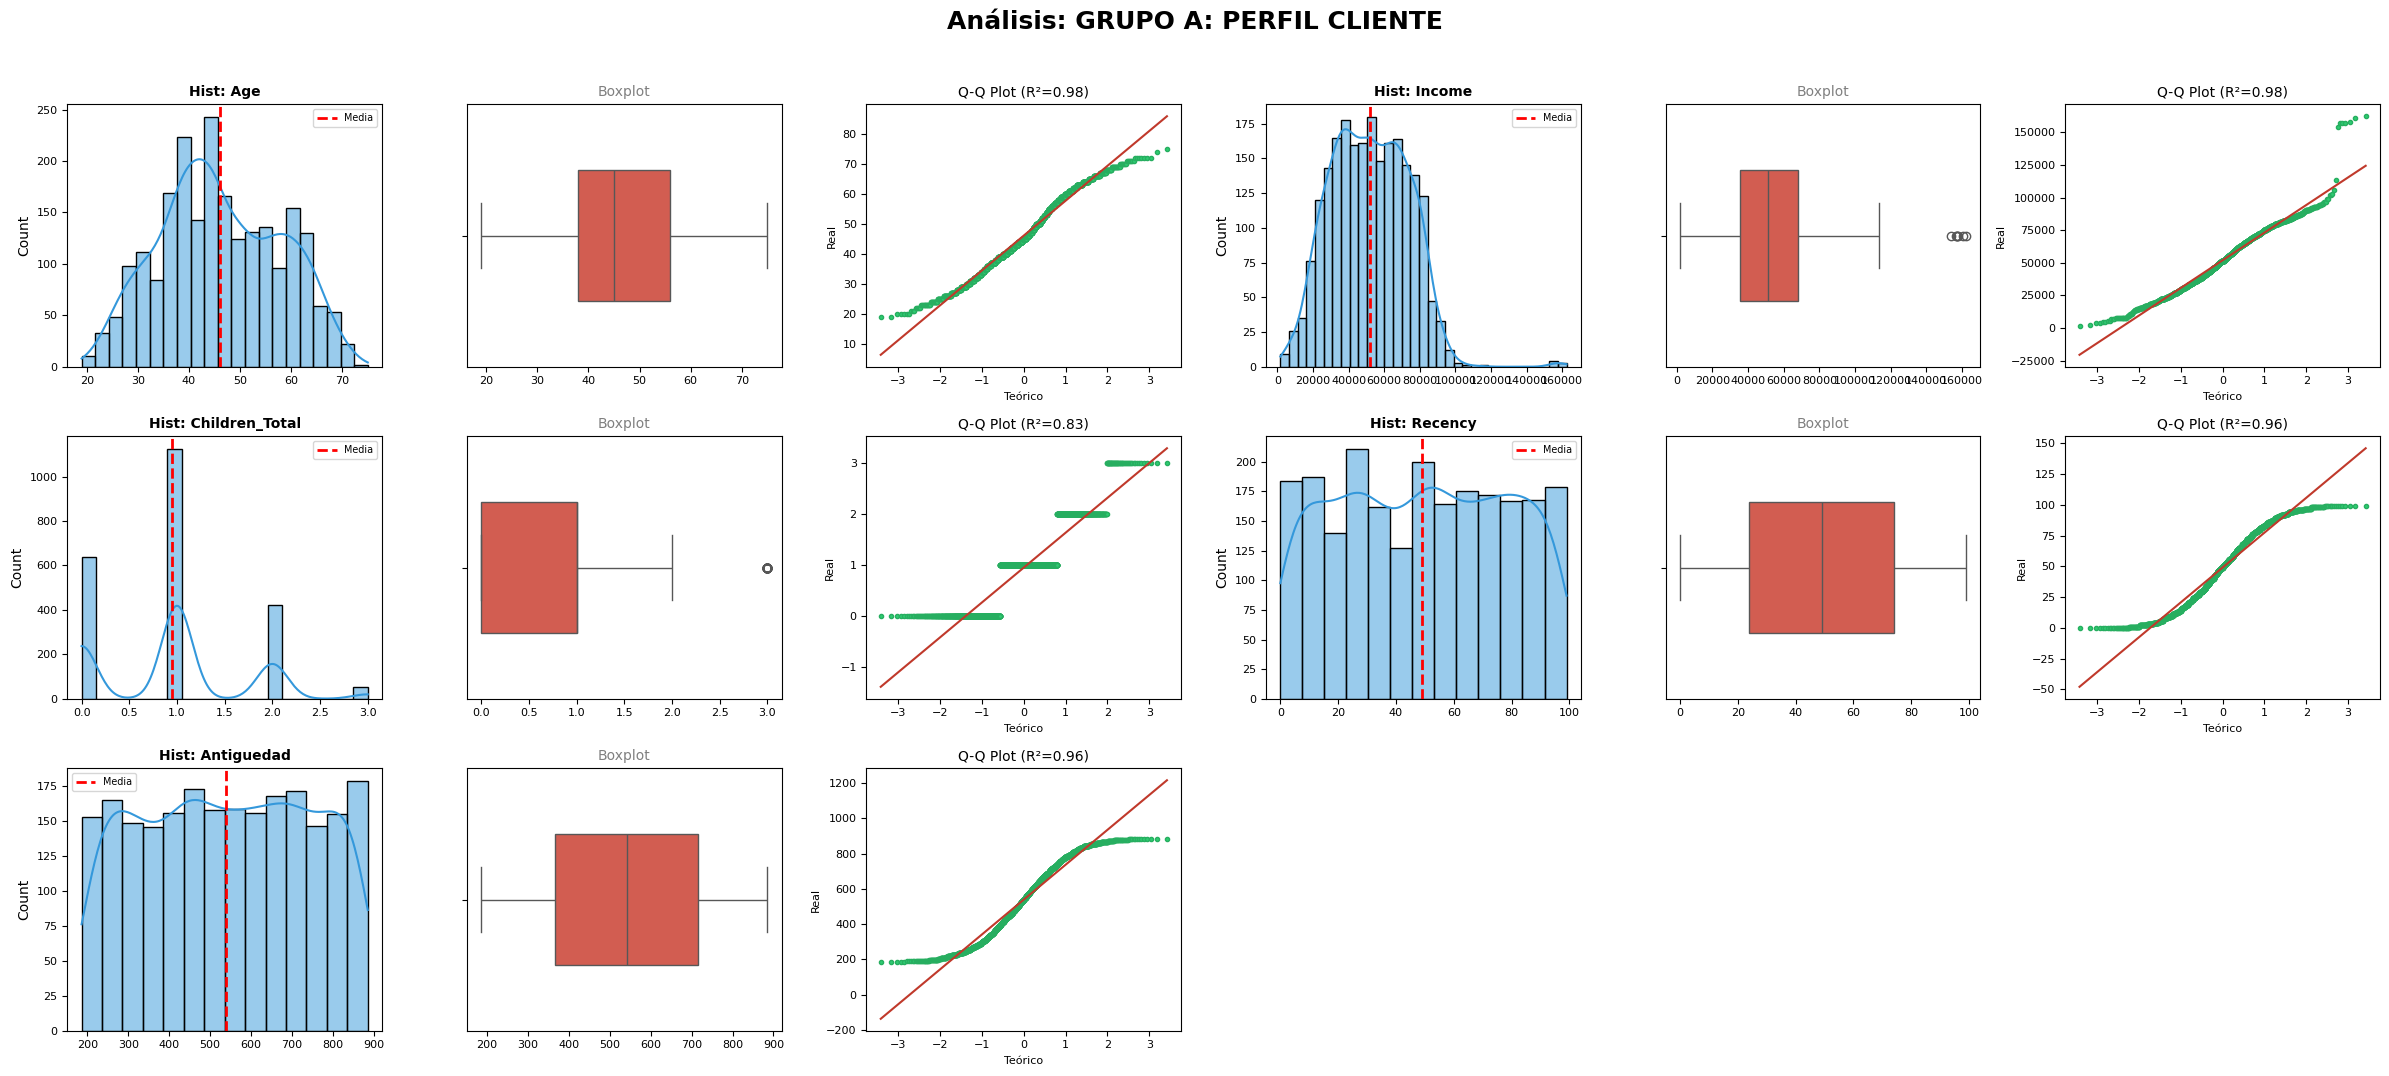

Resumen Estadístico - GRUPO A: PERFIL CLIENTE


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Age,46.10,45.0,11.70,0.09,-0.80,1.7e-15
1,Income,51952.61,51381.5,21411.47,0.35,0.76,6.2e-19
2,Children_Total,0.95,1.0,0.75,0.42,-0.25,1.1e-43
3,Recency,49.12,49.0,28.96,-0.00,-1.20,5.9e-26
4,Antiguedad,539.77,542.0,202.18,-0.02,-1.20,7.7e-26


In [17]:
analizar_grupo("GRUPO A: PERFIL CLIENTE", vars_num_perfil, df_clean)

#### **Análisis del Grupo A: PERFIL CLIENTE**

Tras la limpieza de outliers y la ingeniería de variables, identificamos tres patrones estadísticos claros:

1. **Variables Normales (`Age` e `Income`):**
    * Ambas presentan una simetría robusta (`Skewness` < 0.5) y un ajuste visual excelente a la normalidad en el Q-Q Plot ($R^2 = 0.98$).
    * La leve cola superior es natural en salarios; el bajo skewness (0.35) confirma que la limpieza de outliers (>200k) fue exitosa.
2. **Variable Discreta (`Children_Total`):**
    * Muestra un comportamiento discreto (números enteros), visible en los "escalones" del Q-Q Plot.
    * La media de **0.95** y la mediana de **1.0** indican que el cliente estándar tiene un hijo. La distribución es bastante equilibrada (Skewness 0.42), sin sesgos extremos hacia familias muy numerosas.
3. **Variables Uniformes (`Recency` y `Antiguedad`):**
    * Se caracterizan por histogramas planos y una **curtosis negativa** ($\approx -1.20$). Esto indica una frecuencia constante de visitas y altas de clientes a lo largo del tiempo, sin estacionalidad marcada ni picos anómalos.

**Conclusiones y Decisiones:**
* **Falso Positivo de Shapiro:** Debido al tamaño de la muestra ($N > 2200$), ignoramos el p-value de Shapiro (demasiado estricto) y aceptamos la normalidad operativa de *Age* e *Income*.
* **Escalado Obligatorio:** Dada la disparidad de magnitudes (Hijos $\approx$ 1 vs Ingresos $\approx$ 52k), será imprescindible aplicar **`StandardScaler`** antes del Clustering para que los ingresos no dominen el cálculo de distancias.

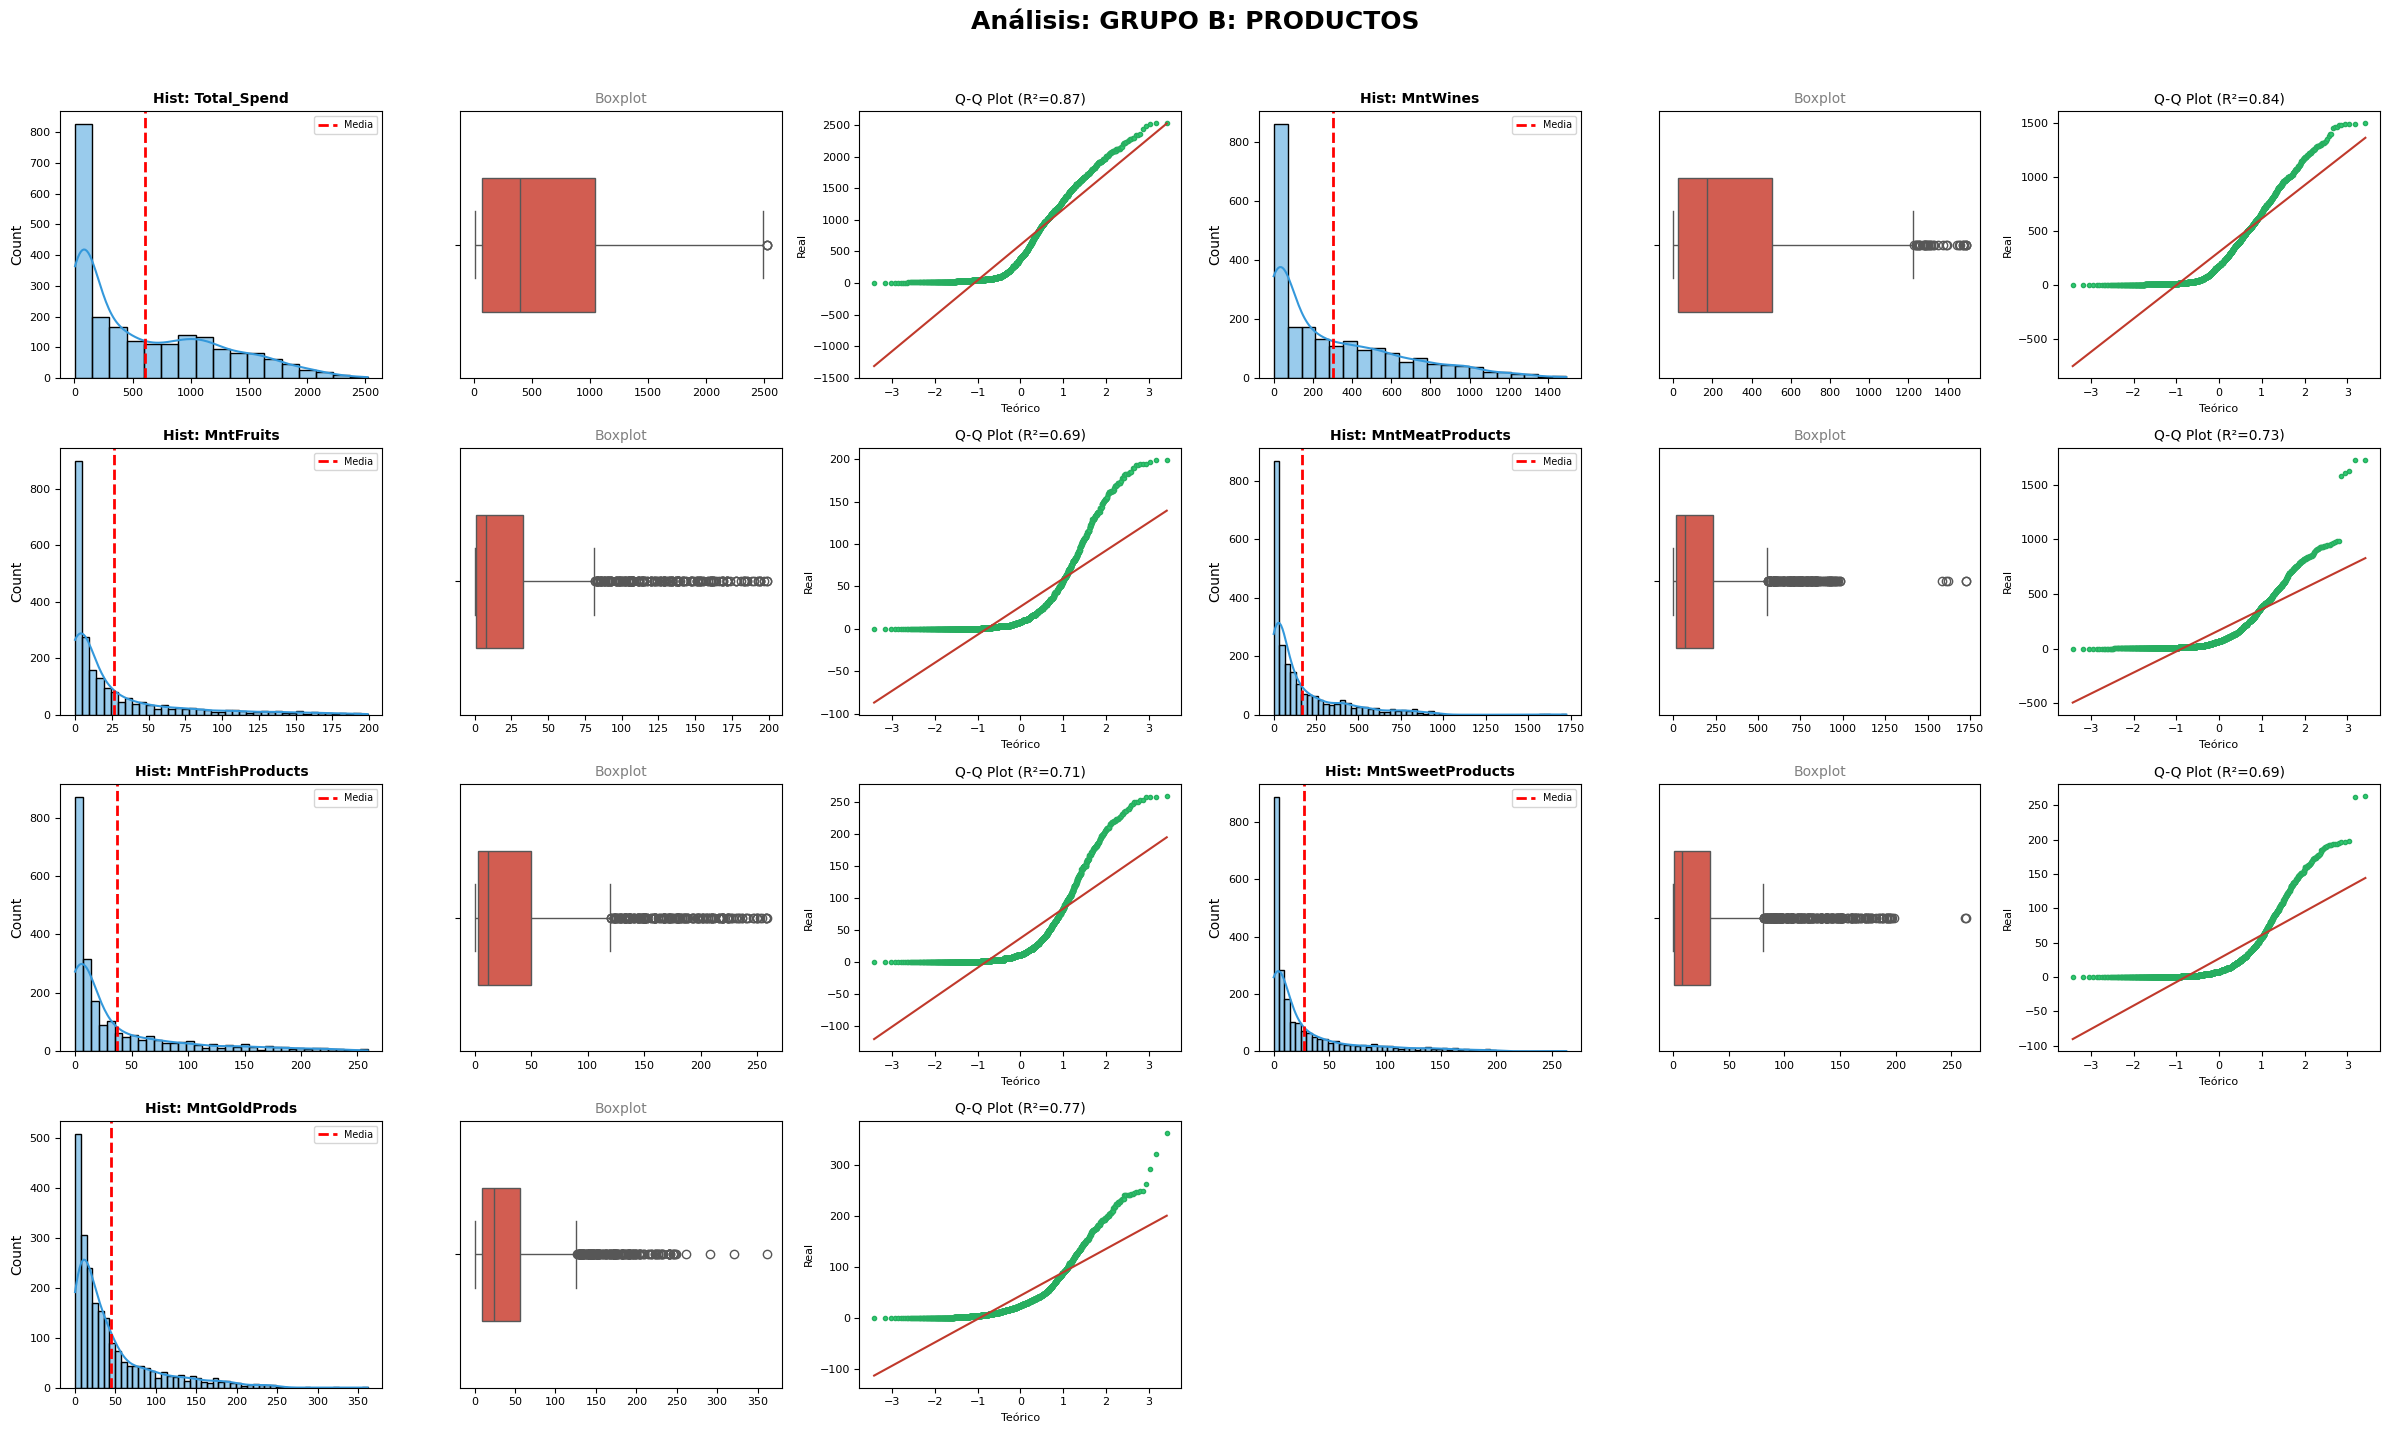

Resumen Estadístico - GRUPO B: PRODUCTOS


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Spend,605.99,396.5,601.87,0.86,-0.34,3.3e-40
1,MntWines,304.13,174.0,336.59,1.18,0.60,6.4e-43
2,MntFruits,26.28,8.0,39.72,2.10,4.07,1.7e-53
3,MntMeatProducts,166.98,67.0,225.69,2.09,5.53,4.0e-51
4,MntFishProducts,37.54,12.0,54.65,1.92,3.10,2.1e-52
5,MntSweetProducts,27.08,8.0,41.30,2.14,4.37,1.2e-53
6,MntGoldProds,43.98,24.0,52.06,1.89,3.56,1.2e-48


In [15]:
analizar_grupo("GRUPO B: PRODUCTOS", vars_num_productos, df_clean)

#### **Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

A diferencia de las variables demográficas, las variables de consumo (`Total_Spend`, `MntWines`, etc.) muestran un patrón sistemático de **Asimetría Positiva Extrema**. No estamos ante una campana de Gauss, sino ante una distribución de "ley de potencial", típica en datos transaccionales.

**1. Diagnóstico Visual:**
* **Histogramas:** Todos tienen forma de "tobogán". La inmensa mayoría de las observaciones se acumulan a la izquierda (gasto bajo o nulo), con una cola muy larga hacia la derecha.
* **Q-Q Plots:** Si nos fijamos en la curva convexa tan pronunciada de los puntos verdes. Se alejan totalmente de la línea roja desde el principio. Los coeficientes $R^2$ bajan drásticamente (**0.69 - 0.87**). Esto es la prueba visual de la No-Normalidad.
* **Boxplots:** Las "cajas" están aplastadas contra el cero y vemos una nube densa de puntos negros a la derecha. En este contexto, estos outliers NO son ruido ni errores; son los Clientes VIP que sostienen la facturación de la empresa. Eliminarlos sería un error de negocio grave.

**2. Análisis de Métricas Clave:**
* **Disparidad Media vs. Mediana:**
* En todas las categorías, la **Media es muy superior a la Mediana**.
    * *Ejemplo Vinos (`MntWines`):* El promedio es **304**, pero el 50% de los clientes gasta menos de **174**.
    * *Ejemplo Fruta (`MntFruits`):* El promedio es **26**, pero la mediana es solo **8**.
    * Unos pocos clientes que gastan mucho "inflan" el promedio. El cliente "típico" gasta poco en frescos y dulces, concentrando su presupuesto en **Vino y Carne**.
* **Asimetría (Skewness) y Curtosis:**
    * **Skewness > 1.0 (e incluso > 2.0):** Confirma el sesgo extremo a la derecha. Incluso la variable agregada `Total_Spend` mantiene un skewness alto (0.86).
    * **Curtosis Elevada:** Variables como `MntMeatProducts` (Curtosis = 5.53) o `MntSweet` (4.37) indican "colas muy pesadas". La probabilidad de encontrar gastos extremos es mucho mayor que en una distribución normal.

**3. Conclusiones y Decisiones de Modelado:**
1. **Rechazo Total de Normalidad:** Los p-values de Shapiro (todos $< 1e^{-40}$) confirman matemáticamente lo que vemos: estas variables no son normales bajo ningún estándar.
2. **Jerarquía de Productos:** Los datos revelan que el negocio se sostiene sobre dos pilares: **Vinos y Carnes** (tienen las medianas y rangos más altos). El resto (Fruta, Pescado, Oro) son compras de nicho o complementarias.
3. **Tratamiento Obligatorio:**
    * Para algoritmos sensibles a la distancia (K-Means, KNN), estas variables sesgarán el modelo si se usan tal cual, ya que las distancias de los VIPs dominarán los clústeres.
    * Será necesario aplicar una transformación para "comprimir" estas colas y acercarlas a una distribución normal, como la Transformación Logarítmica (`np.log1p`) antes de escalar los datos.

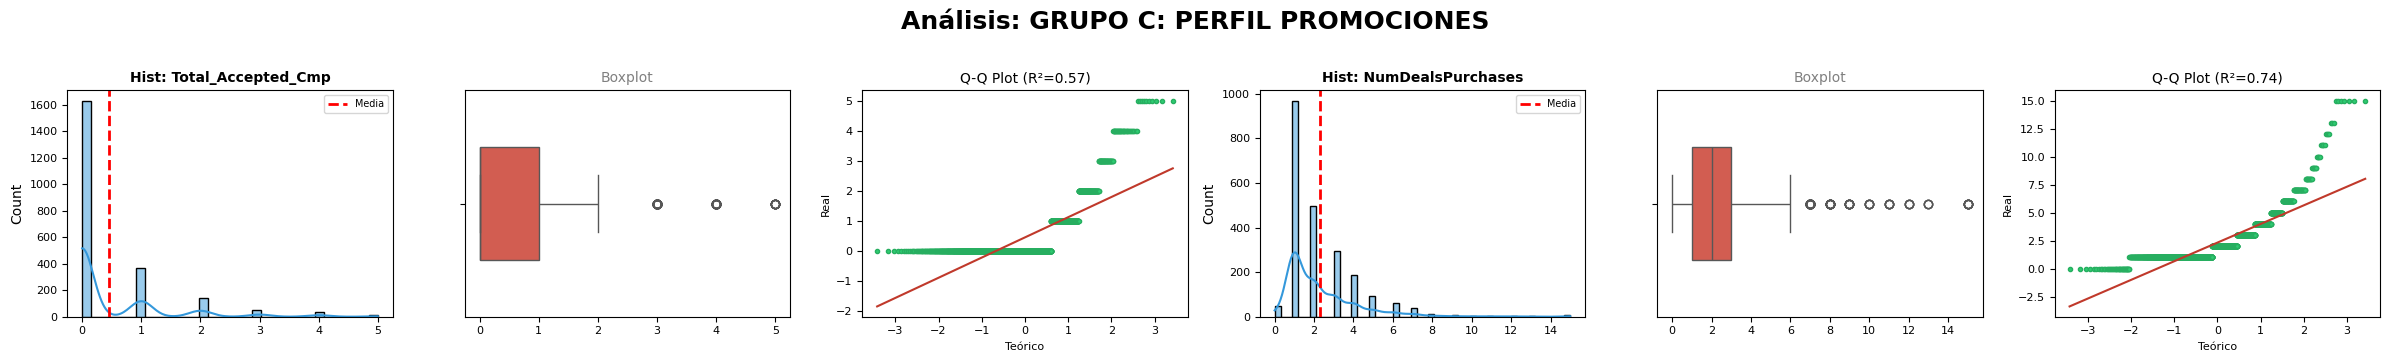

Resumen Estadístico - GRUPO C: PERFIL PROMOCIONES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Accepted_Cmp,0.45,0.0,0.89,2.44,6.33,2.5e-59
1,NumDealsPurchases,2.33,2.0,1.93,2.42,8.93,1.7e-50


In [16]:
analizar_grupo("GRUPO C: PERFIL PROMOCIONES", vars_num_promo, df_clean)

#### **Análisis del Grupo C: PROMOCIONES (Engagement vs. Oportunidad)**

El análisis de este grupo nos muestra dos caras muy distintas de la interacción cliente-empresa: la **Fidelidad de Marca** (`Accepted_Cmp`) y la **Sensibilidad al Precio** (`Deals`). Ambas presentan distribuciones altamente sesgadas y discretas.

**1. `Total_Accepted_Cmp`: La Realidad del "Engagement" (Fidelidad)**
* **El Dominio del Cero:**
    * La Mediana es **0** y la Media es bajísima (**0.45**).
    * El histograma muestra una barra gigante en el 0. Esto significa que **la inmensa mayoría de los clientes ignora las campañas de marketing**. Es un comportamiento de "cero-inflado".
* **Los Outliers son los "Héroes":**
    * En este caso, los valores atípicos (1, 2, 3, 4, 5) que vemos en el Boxplot **NO son errores**.
    * Aunque estadísticamente son "raros" (Skewness 2.44, Kurtosis 6.33), para el negocio son el segmento más valioso. Estos "Super Fans" que aceptan múltiples campañas son los clientes más comprometidos y rentables.
* **No-Normalidad:** El Q-Q Plot escalonado y con un $R^2$ de 0.57 confirma que es una variable discreta que no sigue ninguna distribución normal.

**2. `NumDealsPurchases`: Los "Cazadores de Ofertas"**
* **Comportamiento de Nicho:**
    * Aunque la mediana es **2 compras** con descuento, la **Kurtosis extrema (8.93)** y el **Skewness (2.42)** nos avisan de una cola muy larga a la derecha.
    * Esto indica que existe un grupo de usuarios intensivos que compran sistemáticamente solo cuando hay ofertas (valores de 5 a 15 en el eje X).
* **Diferencia con Fidelidad:**
    * Es crucial notar que aceptar campañas (fidelidad) y buscar ofertas (precio) son comportamientos distintos. Un cliente puede tener `Deals` alto y `Accepted_Cmp` bajo (un cliente que solo compra rebajas y no le interesa la marca en sí).

**Conclusión Estratégica para el Modelo:**
   * Estas variables actuarán como **"separadores de nicho"** en el algoritmo de K-Means.
   * Mientras que las variables de Gasto (Grupo B) separan por "Poder Adquisitivo", estas variables (Grupo C) separarán por **"Actitud Psicológica"** (¿Le gusta la marca o le gusta el precio?).
   * Al ser variables de conteo con muchos ceros y colas largas, se beneficiarán enormemente de un escalado robusto, aunque su naturaleza discreta siempre generará clústeres muy marcados.

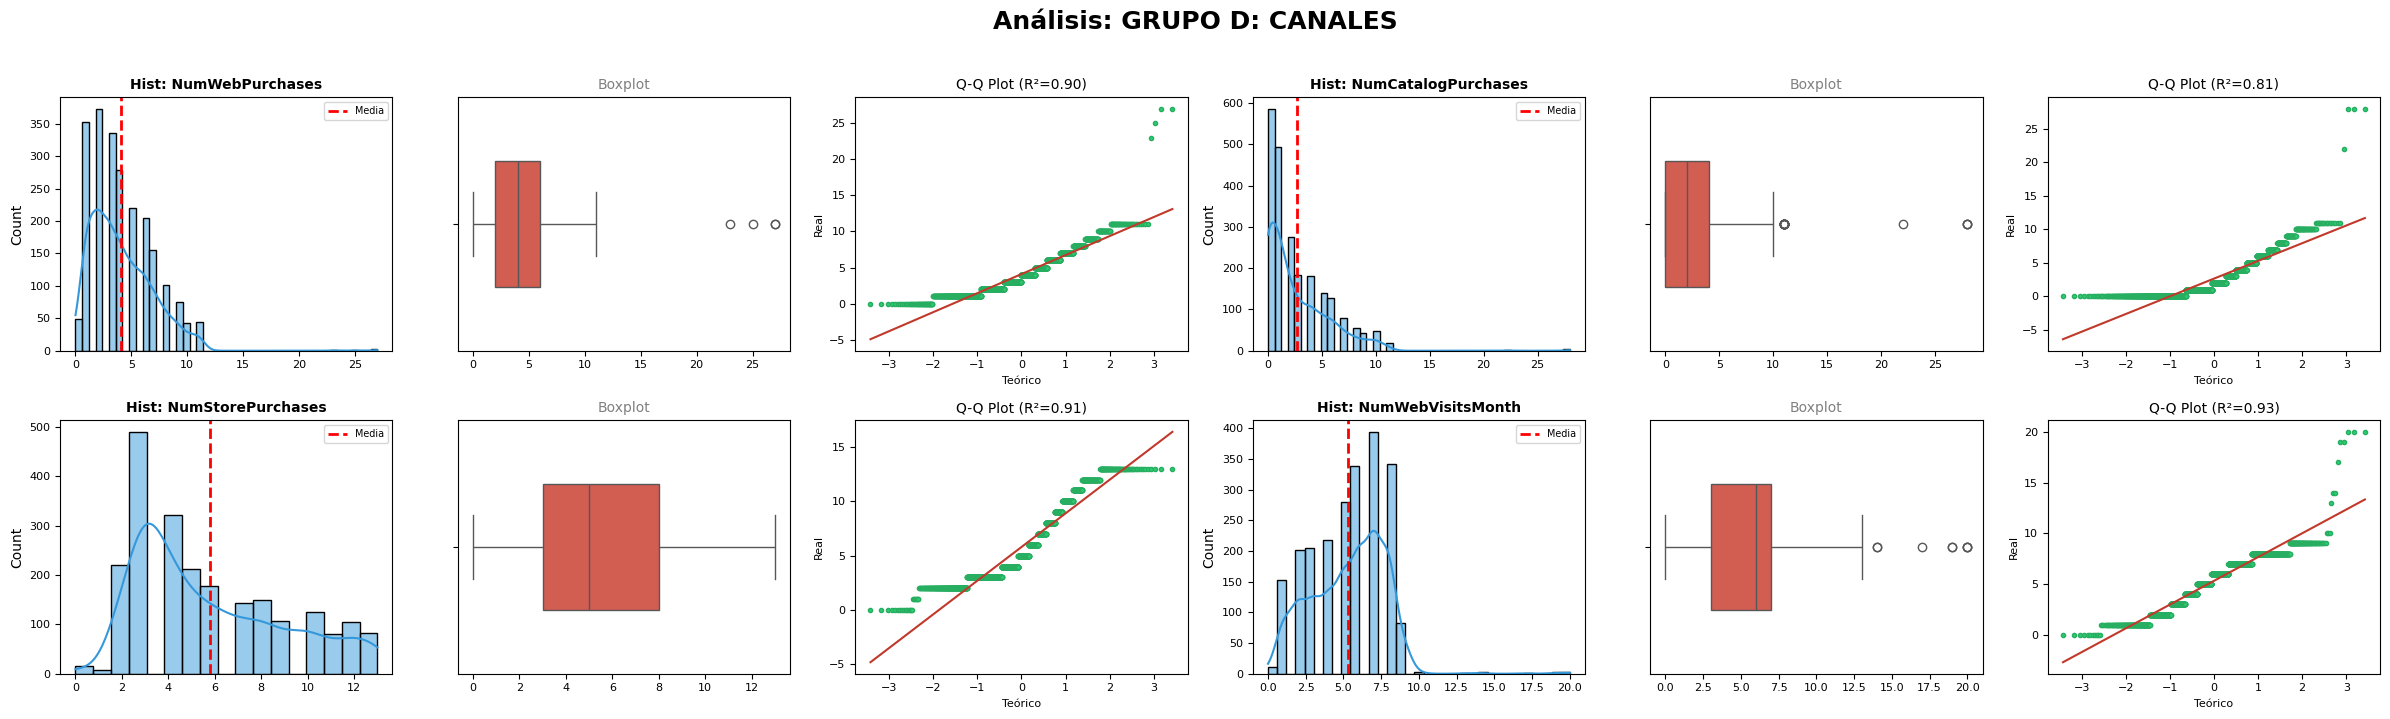

Resumen Estadístico - GRUPO D: CANALES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,NumWebPurchases,4.09,4.0,2.78,1.38,5.70,3.4e-36
1,NumCatalogPurchases,2.66,2.0,2.92,1.88,8.05,5.2e-45
2,NumStorePurchases,5.80,5.0,3.25,0.70,-0.62,3.0e-35
3,NumWebVisitsMonth,5.32,6.0,2.43,0.21,1.82,3.6e-31


In [17]:
analizar_grupo("GRUPO D: CANALES", vars_num_canales, df_clean)

#### **Análisis del Grupo D: CANALES (Comportamiento de Compra)**

En este grupo analizamos la frecuencia de uso de los distintos puntos de contacto. Los datos presentan un comportamiento híbrido entre la normalidad y la asimetría de nicho.

**1. Tienda Física vs. Digital (La Batalla de los Canales):**
* **`NumStorePurchases` (La Reina):**
    * Es el canal dominante con la media más alta (**5.80** compras).
    * **Visualmente:** Es la distribución más "aplanada" (Kurtosis negativa de **-0.62**). Esto es muy relevante: indica que el uso de la tienda física es **democrático y generalizado**. No hay un pico agudo; una gran variedad de clientes compra entre 3 y 8 veces.
    * **Skewness (0.70):** Es moderado. Aunque no es normal perfecta, es la variable de compra más equilibrada del dataset.
* **`NumWebPurchases` (El Aspirante):**
    * Media de **4.09**. Tiene una forma más "picuda" y sesgada (Skew 1.38, Kurtosis 5.70) que la tienda.
    * Esto sugiere que, aunque mucha gente compra online, existe un grupo más específico de compradores digitales intensivos (la cola derecha) que eleva la curtosis.

**2. El Canal de Nicho (Catálogo):**
* **`NumCatalogPurchases`:**
    * **Comportamiento Exclusivo:** Tiene la media más baja (**2.66**) pero la **Kurtosis más alta del grupo (8.05)**.
    * La inmensa mayoría de clientes apenas usa este canal (barras altas en 0, 1 o 2). Sin embargo, la curtosis extrema nos avisa de que existen "Heavy Users" del catálogo que lo usan masivamente (outliers llegando a 28 compras). Es un canal de nicho puro.

**3. Visitas Web (`NumWebVisitsMonth`):**
* **La "Casi Normal" del grupo:**
    * Junto con la Edad, esta variable es la que mejor comportamiento estadístico presenta.
    * **Skewness (0.21):** Es casi simétrica. La media (5.3) y mediana (6.0) están muy cerca.
    * El tráfico web es constante y predecible. La gente entra a mirar ("Window Shopping") de forma regular, independientemente de si acaban comprando mucho o poco.

**Observación Técnica Importante (Los "Escalones"):**
Los Q-Q Plots (especialmente en *WebVisits* o *StorePurchases*), los puntos verdes forman escaleras. Como otra vez esto indica que son variables discretas (números enteros), no continuas.
* Esto hace que el test de Shapiro falle siempre (p-value minúsculo), pero visualmente confirmamos que `NumWebVisitsMonth` y `NumStorePurchases` son lo suficientemente robustas para trabajar sin transformaciones agresivas.

**Resumen:**
"La Tienda Física es el canal principal y más transversal (uso generalizado). El Catálogo es un canal de nicho con usuarios muy intensivos. Las visitas web siguen un patrón normal, lo que sugiere un tráfico digital saludable y predecible que funciona como paso previo a la compra (ROPO)."

### Análisis Bivariante: Relaciones y Drivers de Negocio

Una vez entendidas las variables por separado, el siguiente paso crítico es analizar **cómo interactúan entre sí**. Nuestro objetivo es descubrir qué factores impulsan el gasto (`Total_Spend`) y la fidelidad (`Total_Accepted_Cmp`).

Para generar una **Matriz de Correlación** legible y estratégica, hemos seleccionado un subconjunto específico de variables clave en lugar de utilizar el dataset completo.

**Criterios de Selección de Variables:**
1. **Visión Agregada (Macro):** Utilizamos las variables resumen creadas (`Total_Spend`, `Children_Total`, `Total_Accepted_Cmp`) en lugar de sus componentes individuales. Esto evita la **redundancia estadística** (obviedades como que "gastar más en vino aumenta el gasto total") y nos permite centrarnos en las relaciones estructurales.
2. **Focus en KPIs de Negocio:** Incluimos métricas financieras (`Income`), demográficas (`Age`), de comportamiento (`Recency`, `Antigüedad`) y de canal (`Web`, `Store`, `Catalog`) para tener una visión 360º del cliente.
3. **Limpieza Visual:** Excluimos identificadores (`ID`) y variables binarias desagregadas para asegurar que el mapa de calor revele los patrones fuertes sin "ruido" visual.

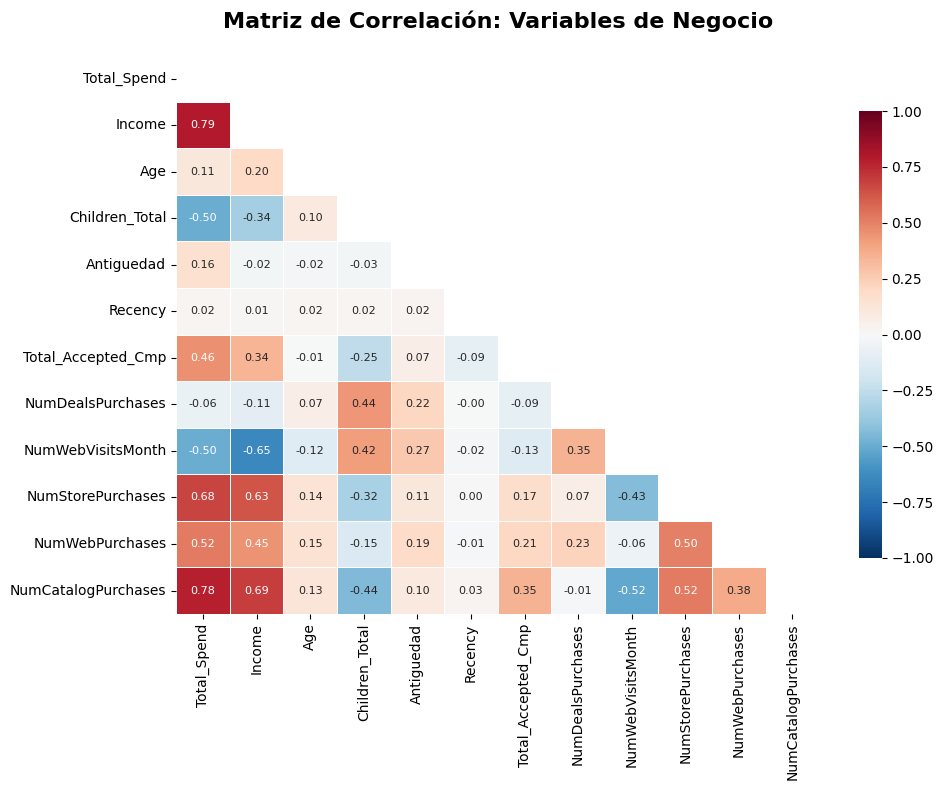

In [18]:
cols_corr = [
    'Total_Spend', 'Income', 'Age', 'Children_Total',
    'Antiguedad', 'Recency',
    'Total_Accepted_Cmp', 'NumDealsPurchases',
    'NumWebVisitsMonth', 'NumStorePurchases', 'NumWebPurchases', 'NumCatalogPurchases'
]

corr_matrix = df_clean[cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            mask=mask,
            linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.title("Matriz de Correlación: Variables de Negocio", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### **Análisis Bivariante: Matriz de Correlación**

El Mapa de Calor revela las conexiones fundamentales que impulsan el negocio. Destacamos cuatro dinámicas críticas para la segmentación:

**1. El Motor Económico (`Income` vs `Total_Spend`):**
* Existe una correlación positiva muy fuerte (**0.79**).
* Como era de esperar, el poder adquisitivo es el predictor principal del gasto. Sin embargo, no es el único factor.

**2. La Sorpresa del Canal: El Poder del Catálogo (`NumCatalogPurchases`):**
* Esta variable presenta una correlación de **0.78** con el Gasto Total, prácticamente idéntica a la de los Ingresos.
* A diferencia de lo que se podría pensar en un entorno digital, **el Catálogo es el canal de los clientes VIP**. Quienes compran por catálogo gastan masivamente, mientras que la correlación con la Web es mucho menor (0.52).

**3. La Paradoja Digital (`NumWebVisitsMonth`):**
* Presenta una correlación **negativa fuerte** con los Ingresos (**-0.65**) y con el Gasto (**-0.50**).
* Se confirma el patrón de "Window Shopping". Los usuarios que más visitan la web suelen ser los de menor poder adquisitivo. Por el contrario, los clientes de alto valor son **eficientes**: visitan poco la web porque compran directamente (probablemente por catálogo o tienda) o saben exactamente lo que quieren.

**4. El "Freno Familiar" (`Children_Total`):**
* Correlación **Negativa** con `Total_Spend` (**-0.50**) y con `Income` (**-0.34**).
* La carga familiar reduce drásticamente el presupuesto para productos de "lujo" (Vino/Oro). Además, la correlación positiva con `NumDealsPurchases` (**0.44**) confirma que las familias son el target principal para las ofertas y descuentos, no para las campañas de exclusividad.

#### **Análisis Visual Detallado: Pairplot**

Una vez que el Mapa de Calor nos ha señalado *dónde* existen relaciones fuertes (por ejemplo, Ingresos vs. Gasto o Hijos vs. Web), utilizamos el **Pairplot** como una "lupa" para inspeccionar la **naturaleza y forma** de dichas conexiones.

**¿Por qué este paso es necesario?**
El coeficiente de correlación (el número en el Heatmap) es un resumen estadístico que asume linealidad, pero puede esconder matices importantes. El Pairplot nos permite:

1. **Validar la Linealidad:** Confirmar si la relación es una línea recta (ideal para modelos lineales) o si tiene curvas (exponencial, logarítmica) que requieran transformaciones.
2. **Detectar Clusters Naturales:** Al colorear por una variable categórica clave (en este caso `Children_Total`), podemos ver si los grupos se separan visualmente en el espacio, lo cual es un indicio excelente de que el algoritmo de Clustering funcionará bien.
3. **Identificar Patrones de Nicho:** Ver comportamientos que solo ocurren en rangos específicos (ej. "solo la gente muy rica compra por catálogo"), algo que un simple número de correlación no puede explicarnos.

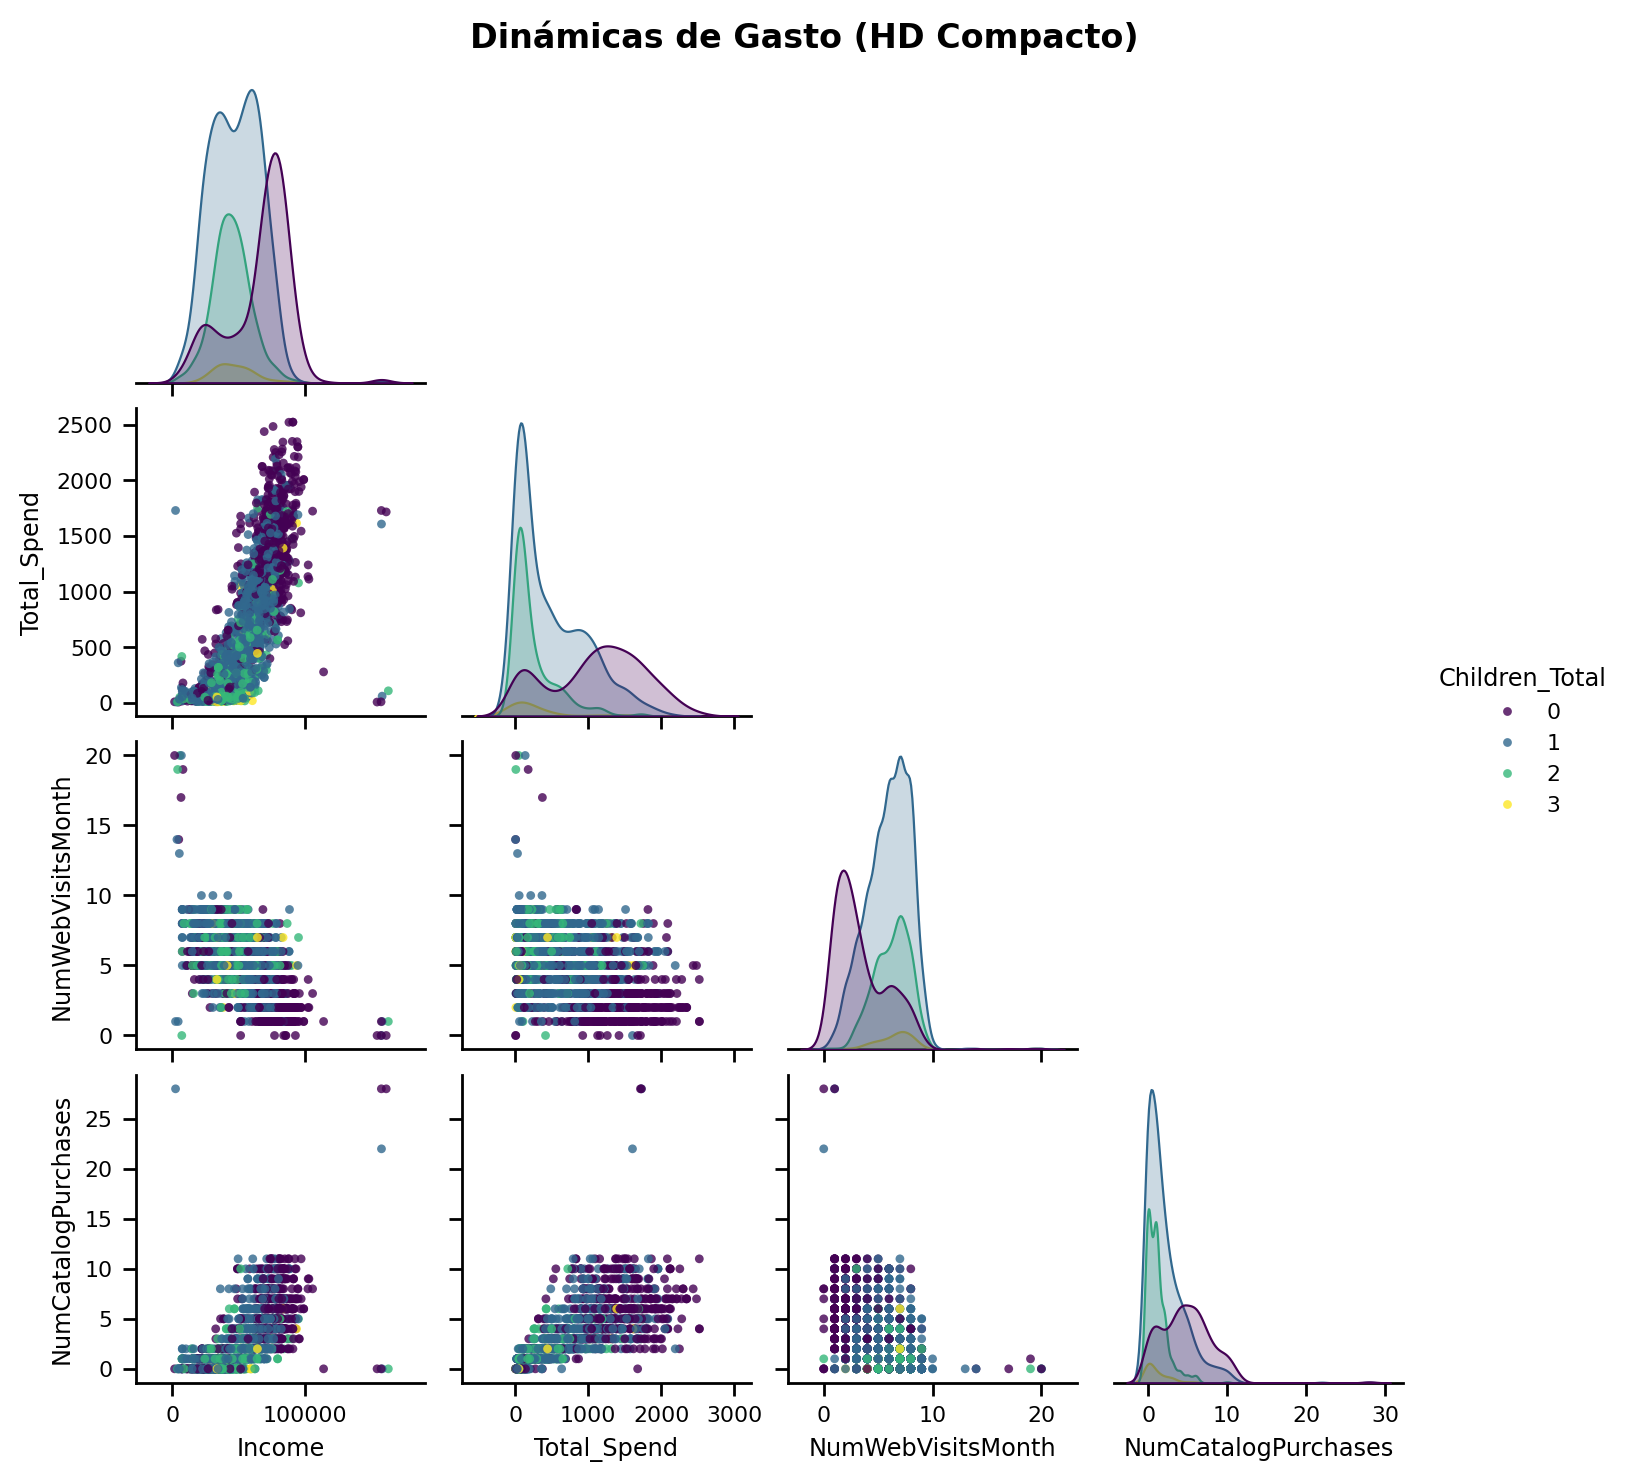

In [18]:
sns.set_context("paper", font_scale=0.9)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 200

vars_zoom = ['Income', 'Total_Spend', 'NumWebVisitsMonth', 'NumCatalogPurchases']

sns.pairplot(df_clean[vars_zoom + ['Children_Total']],
             hue='Children_Total',
             palette='viridis',
             corner=True,
             height=1.8,
             aspect=1,
             plot_kws={'alpha': 0.8, 's': 10, 'edgecolor': 'none'})

plt.suptitle("Dinámicas de Gasto (HD Compacto)", y=1.02, fontsize=12, fontweight='bold')
plt.show()

sns.set_context("notebook")

#### **Análisis Visual Detallado: Dinámicas de Gasto y Familia**

Este gráfico confirma visualmente que la **estructura familiar** es el factor discriminante más potente del dataset. Los colores (0 hijos = Morado, 3 hijos = Amarillo) nos cuentan una historia clara:

**1. La Brecha de Riqueza y Gasto (`Income` vs `Total_Spend`):**
* **El Clúster "Elite" (Puntos Morados - 0 Hijos):** Dominan completamente la esquina superior derecha. Son clientes con altos ingresos (>60k) y gasto masivo. Al no tener carga familiar, su renta disponible se va directa al consumo.
* **El Clúster "Presupuesto Familiar" (Verde/Amarillo - 2 o 3 Hijos):** Están confinados en la esquina inferior izquierda. Aunque sus ingresos suban, su gasto se mantiene bajo ("techo de cristal"). Esto valida la hipótesis de que el dinero se desvía a necesidades básicas no registradas aquí.

**2. El Comportamiento Digital Inverso (`NumWebVisitsMonth`):**
* Miramos el gráfico de densidad (la montaña) en la esquina inferior derecha.
    * **Pico Morado (0 hijos):** Está a la izquierda (0-4 visitas). Visitan poco.
    * **Pico Verde/Amarillo (Familias):** Está a la derecha (6-8 visitas). Visitan mucho.
* Esto confirma visualmente el fenómeno de **"Window Shopping"**. Las familias visitan la web constantemente (probablemente buscando ofertas o comparando precios), mientras que los clientes de alto valor compran de forma eficiente sin navegar tanto.

**3. La Exclusividad del Catálogo (`NumCatalogPurchases`):**
* Observamos el cruce entre `Income` y `Catalog`.
* Tiene forma de **"Palo de Hockey"**. El canal de catálogo es prácticamente inexistente para las familias (puntos amarillos/verdes en el suelo). Solo se activa exponencialmente para los clientes sin hijos y con altos ingresos.

**Conclusión para el Modelo:**
No necesitamos algoritmos complejos para ver que **ya existen grupos separados**.
   * **Grupo A:** Solteros/Parejas ricas (Morado) -> Objetivo de campañas de Lujo/Catálogo.
   * **Grupo B:** Familias numerosas (Amarillo) -> Objetivo de Descuentos/Web.<br>
El Clustering matemático simplemente pondrá una etiqueta formal a esta separación visual que acabamos de detectar.

#### Integración Espacial: Del 2D al 3D

Aunque el Pairplot anterior nos ha mostrado relaciones bidimensionales claras (par a par), la realidad de nuestros clientes es multidimensional. Para confirmar definitivamente la existencia de grupos separables antes de aplicar el algoritmo de Clustering, generamos una proyección espacial tridimensional combinando las tres variables más críticas: Dinero (Income), Gasto (Total_Spend) y Comportamiento (WebVisits), coloreando por Estructura Familiar.

In [20]:
fig = px.scatter_3d(df_clean,
                    x='Income',
                    y='Total_Spend',
                    z='NumWebVisitsMonth',
                    color='Children_Total',
                    opacity=0.7,
                    size_max=10,
                    title="Exploración 3D Interactiva",
                    labels={'Children_Total': 'Hijos'},
                    color_continuous_scale='Viridis')

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

Ahora generamos el mismo grafico 3d en 2d para visualizarlo en el informe:

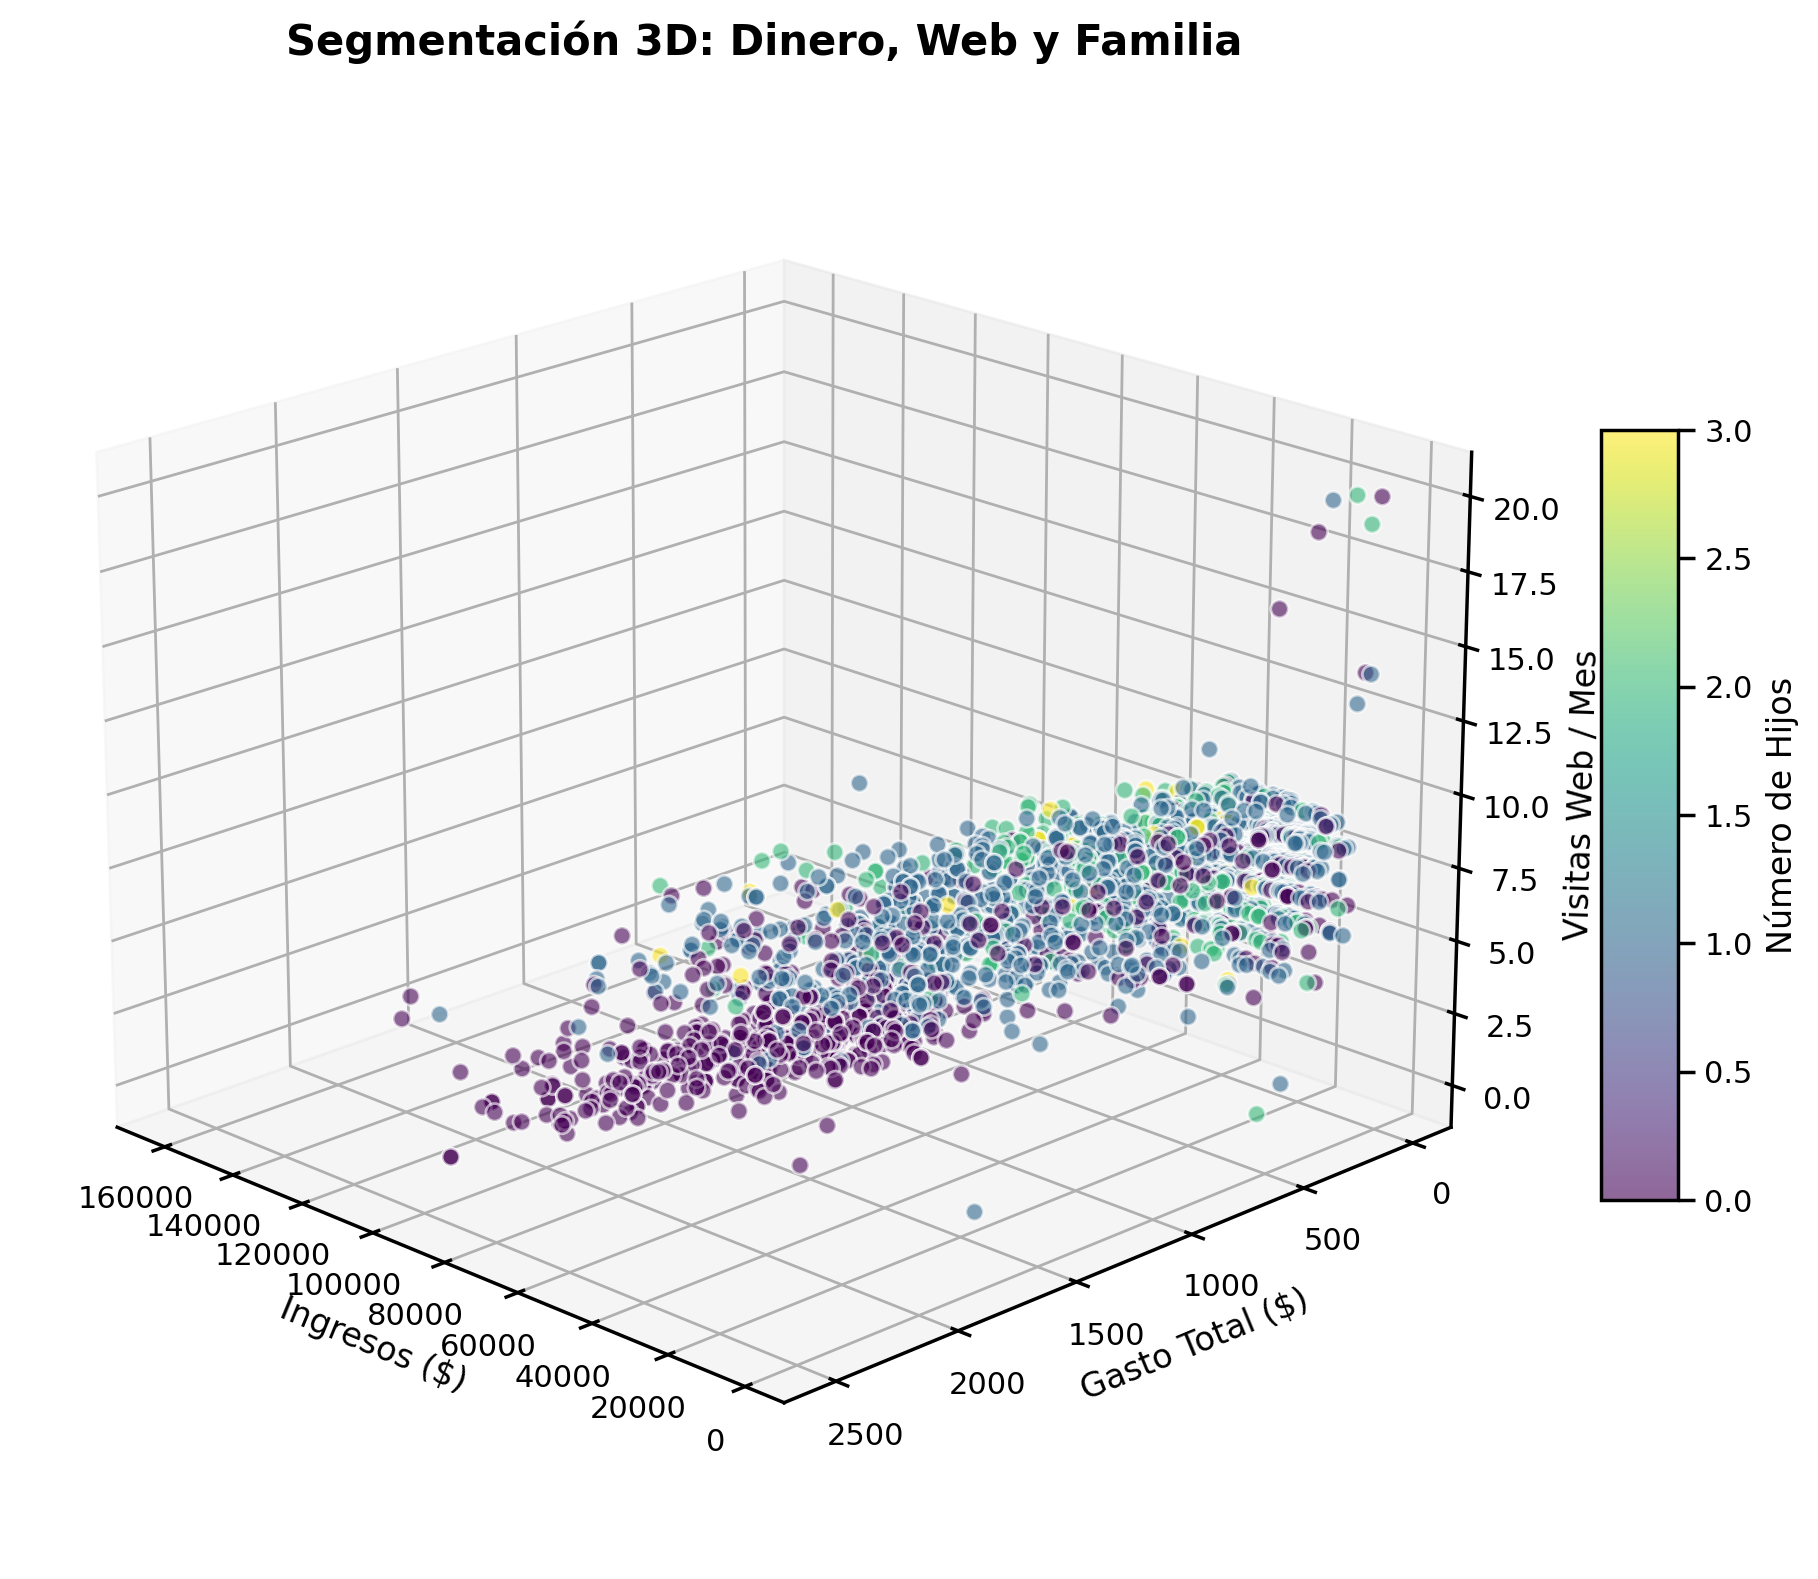

In [21]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x = df_clean['Income']
y = df_clean['Total_Spend']
z = df_clean['NumWebVisitsMonth']
c = df_clean['Children_Total']

img = ax.scatter(x, y, z, c=c, cmap='viridis', s=40, alpha=0.6, edgecolors='w')

ax.set_xlabel('Ingresos ($)')
ax.set_ylabel('Gasto Total ($)')
ax.set_zlabel('Visitas Web / Mes')
ax.set_title('Segmentación 3D: Dinero, Web y Familia', fontsize=15, fontweight='bold')

cbar = fig.colorbar(img, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Número de Hijos')

ax.view_init(elev=20, azim=135)

plt.show()

#### **Segmentación Espacial 3D**

La proyección tridimensional revela una topología fascinante que valida todas nuestras hipótesis anteriores. Al observar la nube de puntos, identificamos dos "galaxias" de clientes que ocupan rincones opuestos del espacio comercial:

**1. El Clúster "Eficiente" (Puntos Morados - Sin Hijos):**
   * Se sitúan "a ras de suelo" (eje Z bajo) pero se extienden hacia la derecha y el fondo (altos Ingresos y Gasto).
   * Tienen mucho dinero, gastan mucho, pero **apenas visitan la web**. Son compradores directos. Su posición baja en el eje Z indica que no necesitan navegar intensivamente para tomar decisiones de compra.

**2. El Clúster "Explorador" (Puntos Verdes/Amarillos - Con Hijos):**
   * Forman una nube que "flota" en la parte superior izquierda.
   * Tienen ingresos limitados y bajo gasto, pero **dominan las alturas del eje Z** (muchas visitas web).
   * Esta "nube flotante" representa a las familias que dedican mucho tiempo a navegar, comparar y buscar oportunidades para optimizar su presupuesto.

**Conclusión Final del EDA Numérico:**
La separación espacial es tan nítida que es visible al ojo humano. Los clientes no están mezclados aleatoriamente; existen **fronteras naturales** definidas por el poder adquisitivo y la carga familiar. Esto garantiza que modelos como **K-Means** tendrán un alto rendimiento al trazar estas fronteras matemáticamente.

### Estudio Variables Categóricas
Primero de todo calculamos cuantas variables categóricas tenemos en el dataset limpio, haciendo un conteo de cada una de ellas.

In [22]:
dict_categorias = {
    "GRUPO A: PERFIL CLIENTE": vars_cat_perfil,
    "GRUPO C: PROMOCIONES (Binarias)": vars_cat_promo
}

for grupo, cols in dict_categorias.items():
    print(f"\n{'='*50}")
    print(f" {grupo}")

    for col in cols:
        print(f"\n>>> VARIABLE: {col}")

        # Conteo y Porcentaje
        conteo = df_clean[col].value_counts()
        porcentaje = df_clean[col].value_counts(normalize=True) * 100

        # Crear tabla visual
        resumen = pd.DataFrame({'Frecuencia': conteo, '% Total': porcentaje.round(2)})
        print(resumen)


 GRUPO A: PERFIL CLIENTE

>>> VARIABLE: Education
            Frecuencia  % Total
Education                      
Graduation        1126    50.36
PhD                485    21.69
Master             370    16.55
2n Cycle           201     8.99
Basic               54     2.42

>>> VARIABLE: Marital_Status
                Frecuencia  % Total
Marital_Status                     
Married                864    38.64
Together               578    25.85
Single                 479    21.42
Divorced               231    10.33
Widow                   77     3.44
Alone                    3     0.13
Absurd                   2     0.09
YOLO                     2     0.09

>>> VARIABLE: Kidhome
         Frecuencia  % Total
Kidhome                     
0              1291    57.74
1               897    40.12
2                48     2.15

>>> VARIABLE: Teenhome
          Frecuencia  % Total
Teenhome                     
0               1155    51.65
1               1029    46.02
2                 52   

#### **Análisis de Variables Categóricas**
La inspección de frecuencias revela problemas de calidad de datos ("Etiquetas Basura") y oportunidades de simplificación para mejorar el rendimiento del modelo.

**1. Perfil Demográfico (Grupo A):**
* **Educación (`Education`):**
    * La mitad de la base (50%) son Graduados universitarios.
    * Existe la categoría `2n Cycle` (8.99%) y `Master` (16.55%). En la práctica, un "Segundo Ciclo" equivale académicamente a una Maestría. Mantenerlas separadas diluye la información.
    * Fusionaremos `2n Cycle` dentro de `Master` para crear una categoría de "Postgrado" más robusta.
* **Estado Civil (`Marital_Status`):**
    * **Dominio de Parejas:** El 64% de los clientes vive en pareja (`Married` + `Together`).
    * **Datos "Basura":** Hemos detectado 3 categorías absurdas con frecuencia irrelevante: `Alone` (3 casos), `Absurd` (2 casos) y `YOLO` (2 casos). Estos 7 registros representan "ruido" puro.
    * Reemplazaremos estas etiquetas por `Single`, ya que representan a personas sin pareja declarada.
* **Quejas (`Complain`):**
    * **Varianza Cero:** El 99.11% de los valores son "0". Solo existen 20 quejas en todo el histórico.
    * Esta variable **no aporta información** para segmentar (no discrimina). Se eliminará del dataset para reducir ruido dimensional.

**2. Rendimiento de Marketing (Grupo C):**
* **Las Campañas:**
    * La aceptación general es baja, oscilando entre el 6% y el 7%.
    * **La "Oveja Negra":** La campaña `AcceptedCmp2` fue un fracaso notable, con solo un 1.34% de éxito.
    * **La Mejor:** La campaña `AcceptedCmp4` y la `AcceptedCmp3` son las más efectivas (~7.3%).
* **Tasa de Conversión (`Response`):**
    * La última campaña tuvo un éxito del **14.94%**. Este es un dato muy positivo comparado con las campañas anteriores, sugiriendo una mejora en la estrategia reciente.

#### **Ejecución de la Limpieza y Refinamiento**

Basándonos en el diagnóstico anterior, aplicamos las siguientes transformaciones directas sobre `df_clean` para estandarizar las categorías y eliminar el ruido antes del modelado:

1. **Unificación Educativa:** Se fusiona `2n Cycle` dentro de `Master`.
2. **Saneamiento Civil:** Se reasignan las etiquetas minoritarias (`YOLO`, `Absurd`, `Alone`) a la categoría `Single`.
3. **Eliminación de Variables:** Se descartan `Complain` (falta de varianza) y los metadatos ya procesados (`ID`, `Year_Birth`, `Dt_Customer`) que no aportan valor predictivo al algoritmo.

In [23]:
df_clean['Education'] = df_clean['Education'].replace({'2n Cycle': 'Master'})

basura_civil = ['YOLO', 'Absurd', 'Alone']
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace(basura_civil, 'Single')

cols_eliminar = ['Complain', 'ID', 'Dt_Customer', 'Year_Birth']
cols_finales_borrar = [c for c in cols_eliminar if c in df_clean.columns]

df_clean = df_clean.drop(columns=cols_finales_borrar)

print(f"Limpieza completada. Variables eliminadas: {cols_finales_borrar}")
print(f"Dimensiones actuales del dataset: {df_clean.shape}")

Limpieza completada. Variables eliminadas: ['Complain', 'ID', 'Dt_Customer', 'Year_Birth']
Dimensiones actuales del dataset: (2236, 28)


#### Análisis Visual Post-Limpieza de Variables Categóricas
Utilizamos gráficos de barras y boxplots para visualizar la distribución de las variables categóricas del Grupo A (Perfil) y su relación con el Gasto Total tras la limpieza.

Esto nos permite validar visualmente las transformaciones aplicadas y entender mejor cómo cada categoría influye en el comportamiento de gasto.

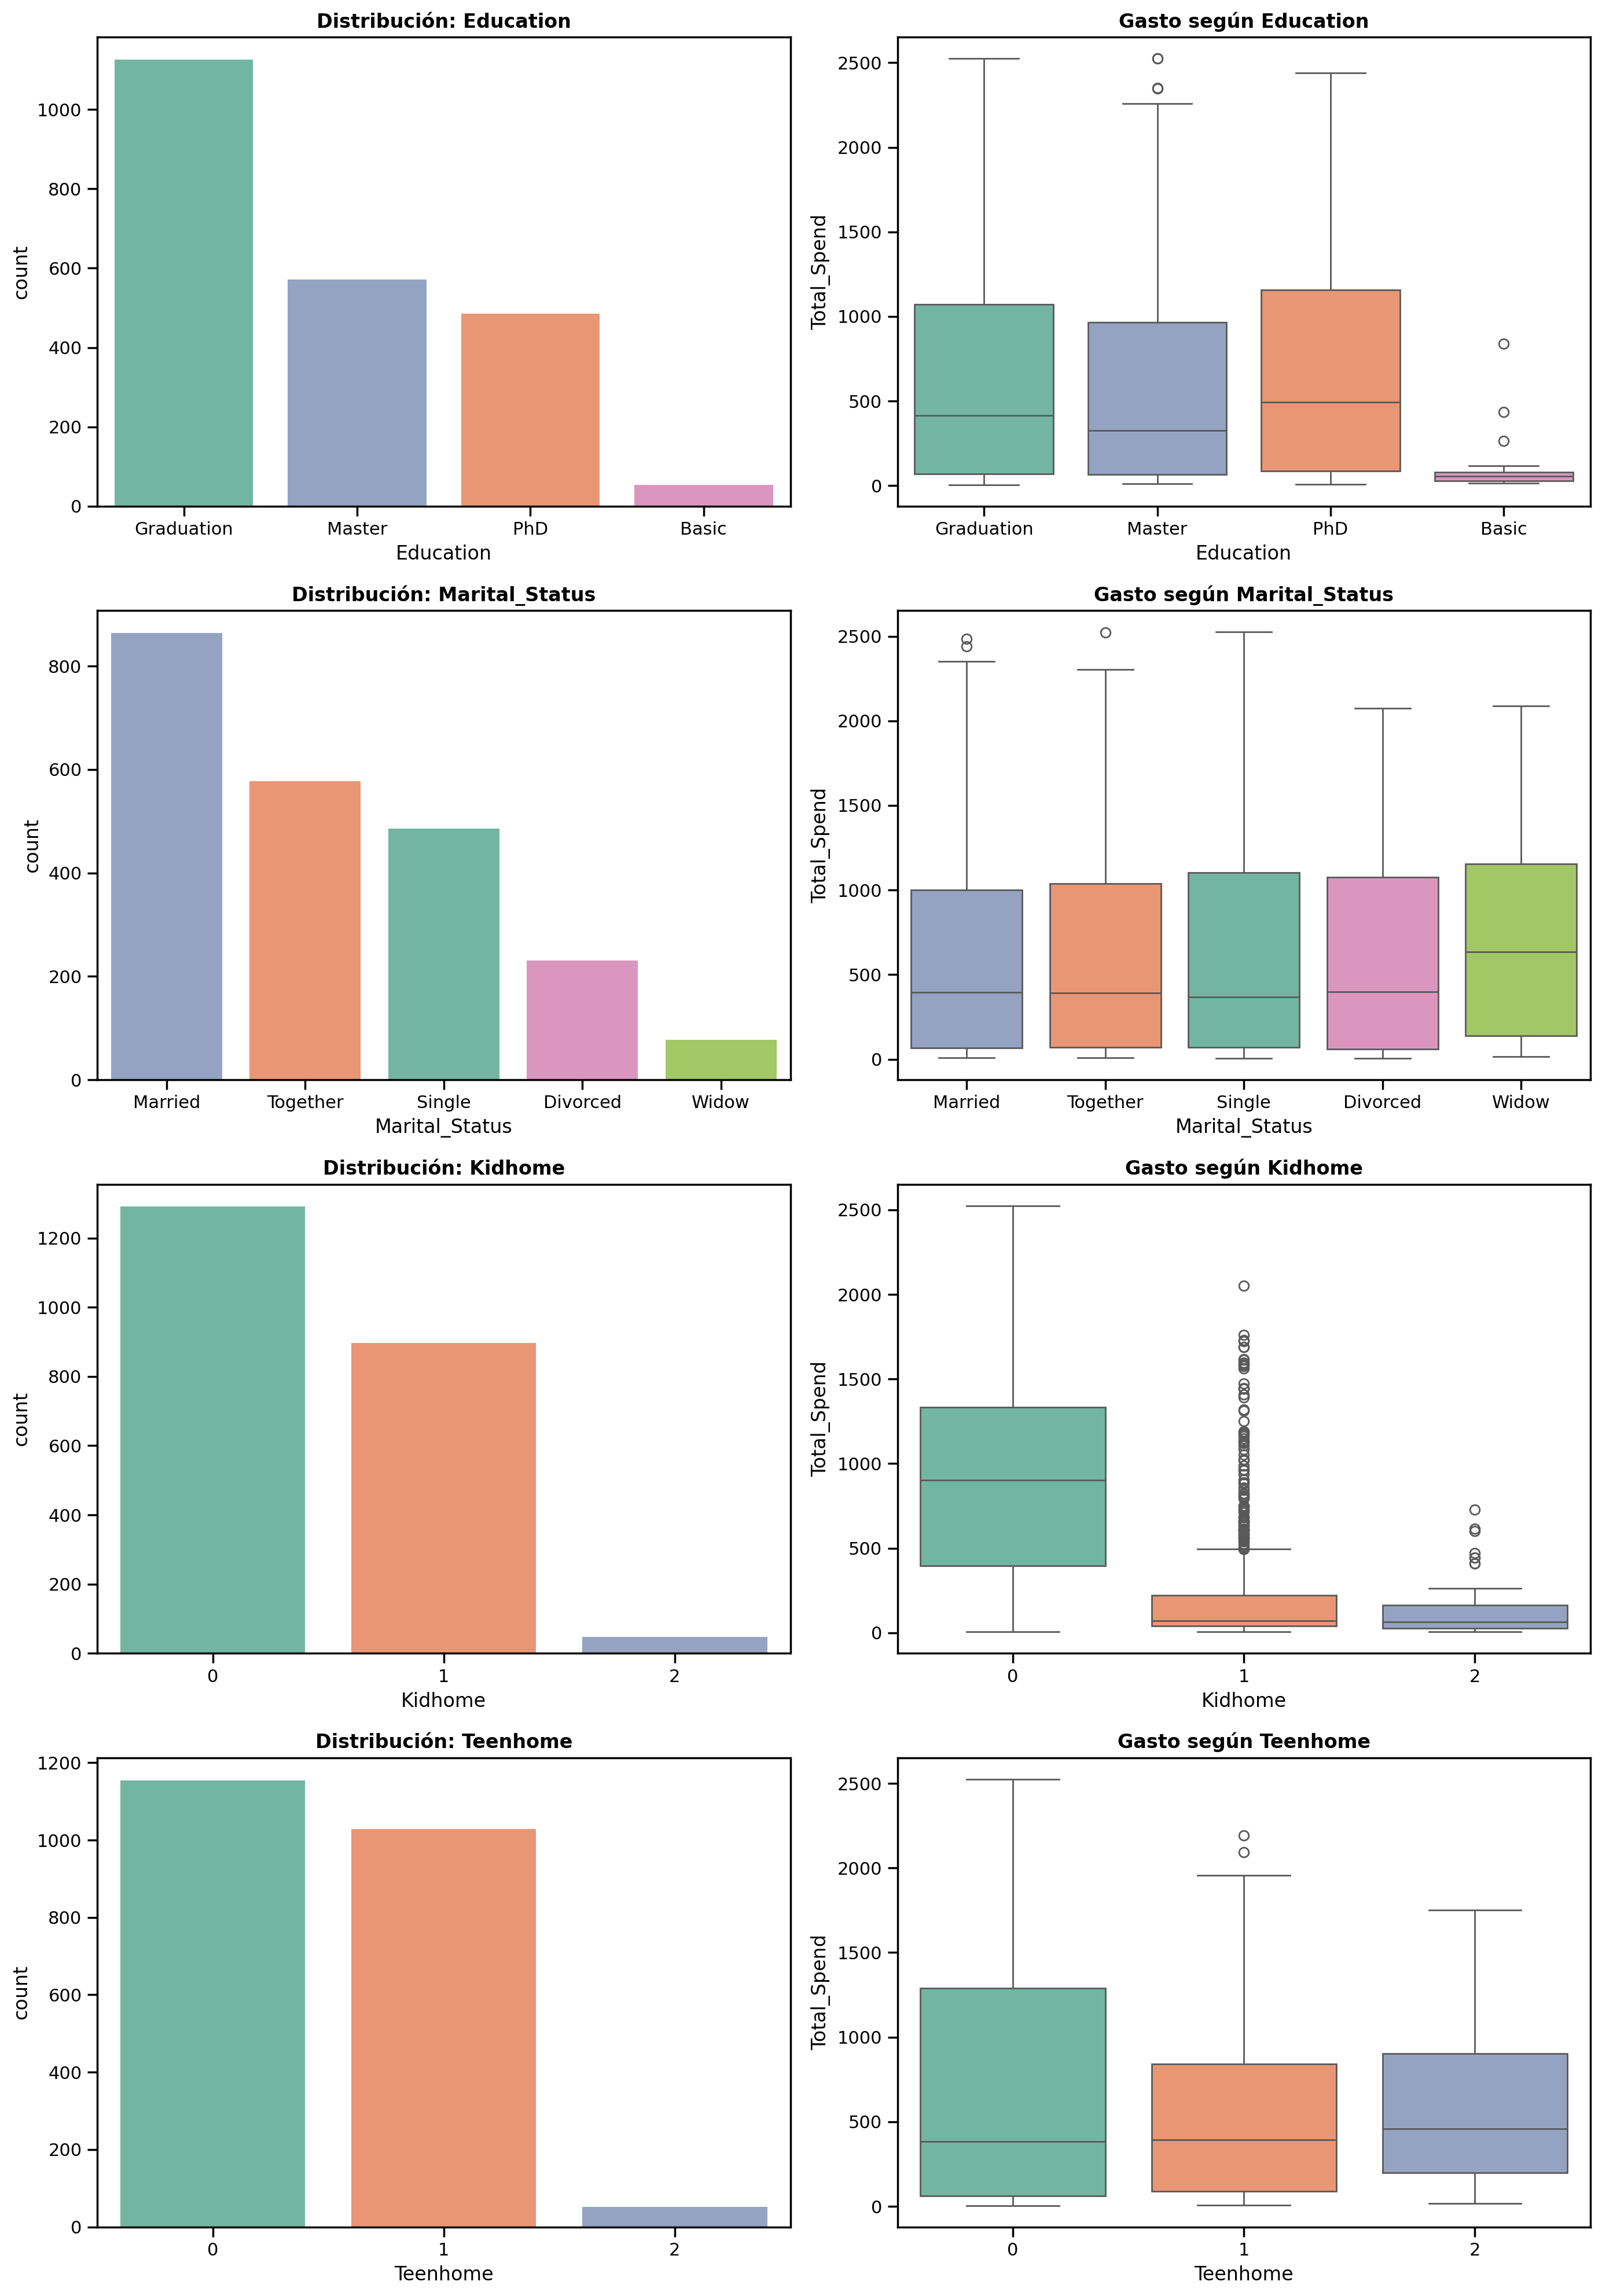

In [24]:
vars_a_graficar = [c for c in vars_cat_perfil if c in df_clean.columns]

fig, axes = plt.subplots(len(vars_a_graficar), 2, figsize=(14, 5 * len(vars_a_graficar)))

for i, col in enumerate(vars_a_graficar):
    sns.countplot(x=col, data=df_clean, ax=axes[i, 0], palette='Set2',
                  hue=col, legend=False, order=df_clean[col].value_counts().index)
    axes[i, 0].set_title(f'Distribución: {col}', fontweight='bold')

    sns.boxplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i, 1], palette='Set2',
                hue=col, legend=False, order=df_clean[col].value_counts().index)
    axes[i, 1].set_title(f'Gasto según {col}', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Análisis Visual del Perfil Demográfico**

La visualización consolida las variables categóricas del **Grupo A (Perfil)** tras la limpieza, revelando qué características definen al cliente de alto valor.

**1. Nivel Educativo (`Education`):**
* **Distribución:** La categoría `Graduation` (Licenciados) es la predominante. La fusión de `Master` y `2n Cycle` ha creado un segundo grupo sólido de postgraduados.
* **Comportamiento de Gasto:**
    * **El segmento "Basic" es de bajo valor:** Su caja de gasto está pegada a cero. Estos clientes tienen muy poco potencial de monetización.
    * Los clientes con `PhD` son los que más gastan. Su mediana es ligeramente superior a la de `Graduation` y `Master`.

**2. Estado Civil (`Marital_Status`):**
* **Limpieza Exitosa:** La categoría `Single` aparece limpia y consistente, habiendo absorbido los valores atípicos.
* **Irrelevancia en el Gasto:** Este es un hallazgo clave. Al observar los boxplots, las medianas de gasto son **sorprendentemente similares** entre `Married`, `Together`, `Single` y `Divorced`.
    * `Widow` (viudos) muestra una caja ligeramente más alta, pero con muy pocos datos.
* El estado civil **NO** es una variable discriminante fuerte para predecir el gasto. Un soltero gasta de forma muy similar a un casado en este negocio.

**3. El Verdadero Freno: Los Hijos (`Kidhome`):**
* **Impacto Brutal:** Esta variable muestra la diferencia más drástica de todo el dataset.
    * **0 Niños:** La caja es alta y amplia (Mediana de gasto > 1000 aprox).
    * **1 Niño:** El gasto colapsa dramáticamente.
* La presencia de un niño pequeño actúa como un "ancla" financiera, pensamos que desvía recursos hacia necesidades no reflejadas en este dataset (educación, salud, ocio infantil). También podria ser para ahorrar para el futuro del niño.

**4. Adolescentes (`Teenhome`):**
* **Impacto Moderado:** Tener adolescentes también reduce el gasto comparado con no tenerlos (0), pero la caída es **menos severa** que con los niños pequeños.
* Esto sugiere que a medida que los hijos crecen, el presupuesto familiar recupera cierto margen para el consumo, aunque no vuelve a los niveles de "sin hijos".

#### Análisis Visual de Variables Categóricas del Grupo C (Promociones)
Similarmente, visualizamos las variables categóricas del Grupo C (Promociones) para entender cómo la aceptación de campañas pasadas influye en el gasto total.

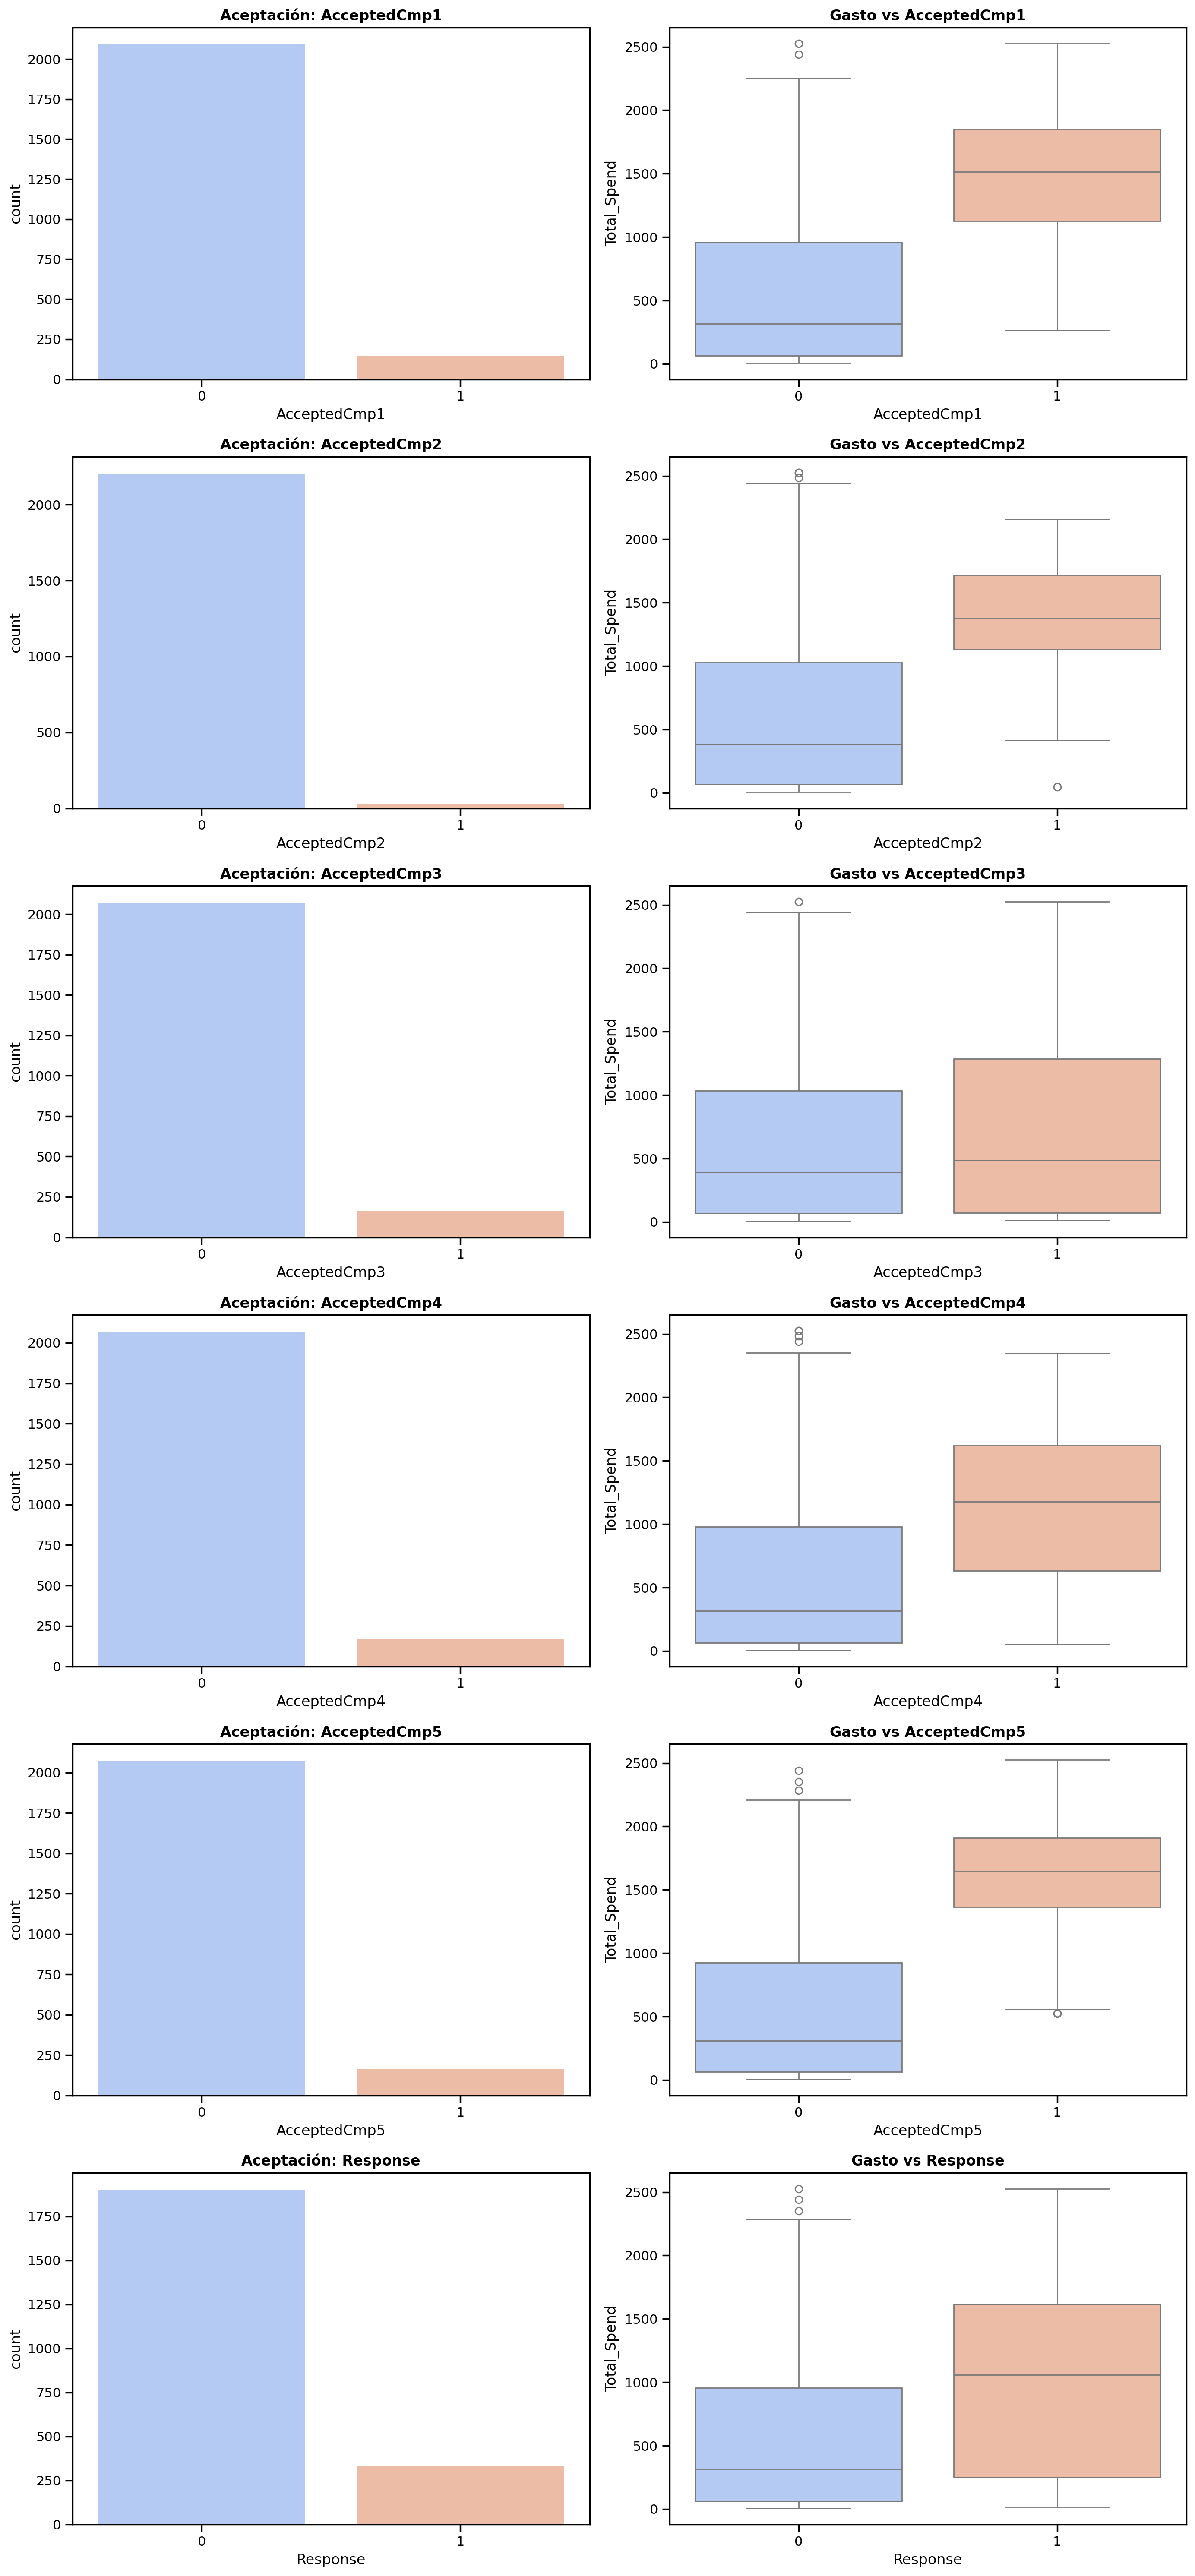

In [25]:
fig, axes = plt.subplots(len(vars_cat_promo), 2, figsize=(14, 5 * len(vars_cat_promo)))

for i, col in enumerate(vars_cat_promo):
    sns.countplot(x=col, data=df_clean, ax=axes[i, 0], palette='coolwarm',
                  hue=col, legend=False)
    axes[i, 0].set_title(f'Aceptación: {col}', fontweight='bold')

    sns.boxplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i, 1], palette='coolwarm',
                hue=col, legend=False)
    axes[i, 1].set_title(f'Gasto vs {col}', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Análisis Visual de Efectividad de Marketing (Grupo C)**

Este panel dashboard cruza la aceptación de las 5 campañas previas y la actual (`Response`) contra el Gasto Total. Los patrones son consistentes y reveladores:

**1. El Patrón "Filtro de Riqueza":**
* **Observación:** En los 6 pares de gráficos, se repite la misma dinámica.
* **Izquierda (Frecuencia):** La inmensa mayoría de clientes rechaza las ofertas (Barras azules gigantes vs. naranjas minúsculas). La tasa de conversión es baja.
* **Derecha (Gasto):** Sin embargo, **los que aceptan (Naranja) son sistemáticamente los que más gastan**.
   * La caja naranja está siempre muy por encima de la azul, con medianas de gasto que pueden ser 3-4 veces mayores.
* **Conclusión:** Las campañas de marketing actúan como un "filtro de oro". Aunque atraen a poca gente, atraen exactamente a la gente correcta (High Value Customers). No son campañas masivas, son campañas de nicho premium.

**2. La Anomalía de la Campaña 2 (`AcceptedCmp2`):**
* **La más exclusiva:** Nos fijamos en la barra naranja del conteo (Fila 2, Izquierda). Es casi invisible. Fue la campaña con menor aceptación histórica (aprox 1%).
* Sin embargo, su boxplot (Derecha) muestra una mediana de gasto altísima. Quien aceptó esta campaña es, casi con seguridad, un cliente "VIP".

**3. La Mejora en la Última Campaña (`Response`):**
* **Mayor Volumen:** La última fila (`Response`) muestra una barra naranja visiblemente más grande que las anteriores. Esto confirma que la última estrategia de marketing logró duplicar la tasa de conversión (llegando al ~15%).
* **Mantenimiento de Valor:** A pesar de atraer a más gente, la caja naranja de gasto sigue estando muy por encima de la azul. Se consiguió aumentar el volumen sin sacrificar la calidad del cliente.

**Resumen de Negocio:**
El "No" (0) es el comportamiento por defecto del cliente promedio/bajo valor. El "Sí" (1) es un indicador casi perfecto de alto poder adquisitivo.

#### Análisis de Densidad de Gasto (Violin Plots)
Los gráficos de violín combinan las ventajas de los boxplots y los histogramas, mostrando la distribución completa del gasto dentro de cada categoría. Esto nos permite entender no solo la mediana y los cuartiles, sino también la **forma y densidad** de los datos.

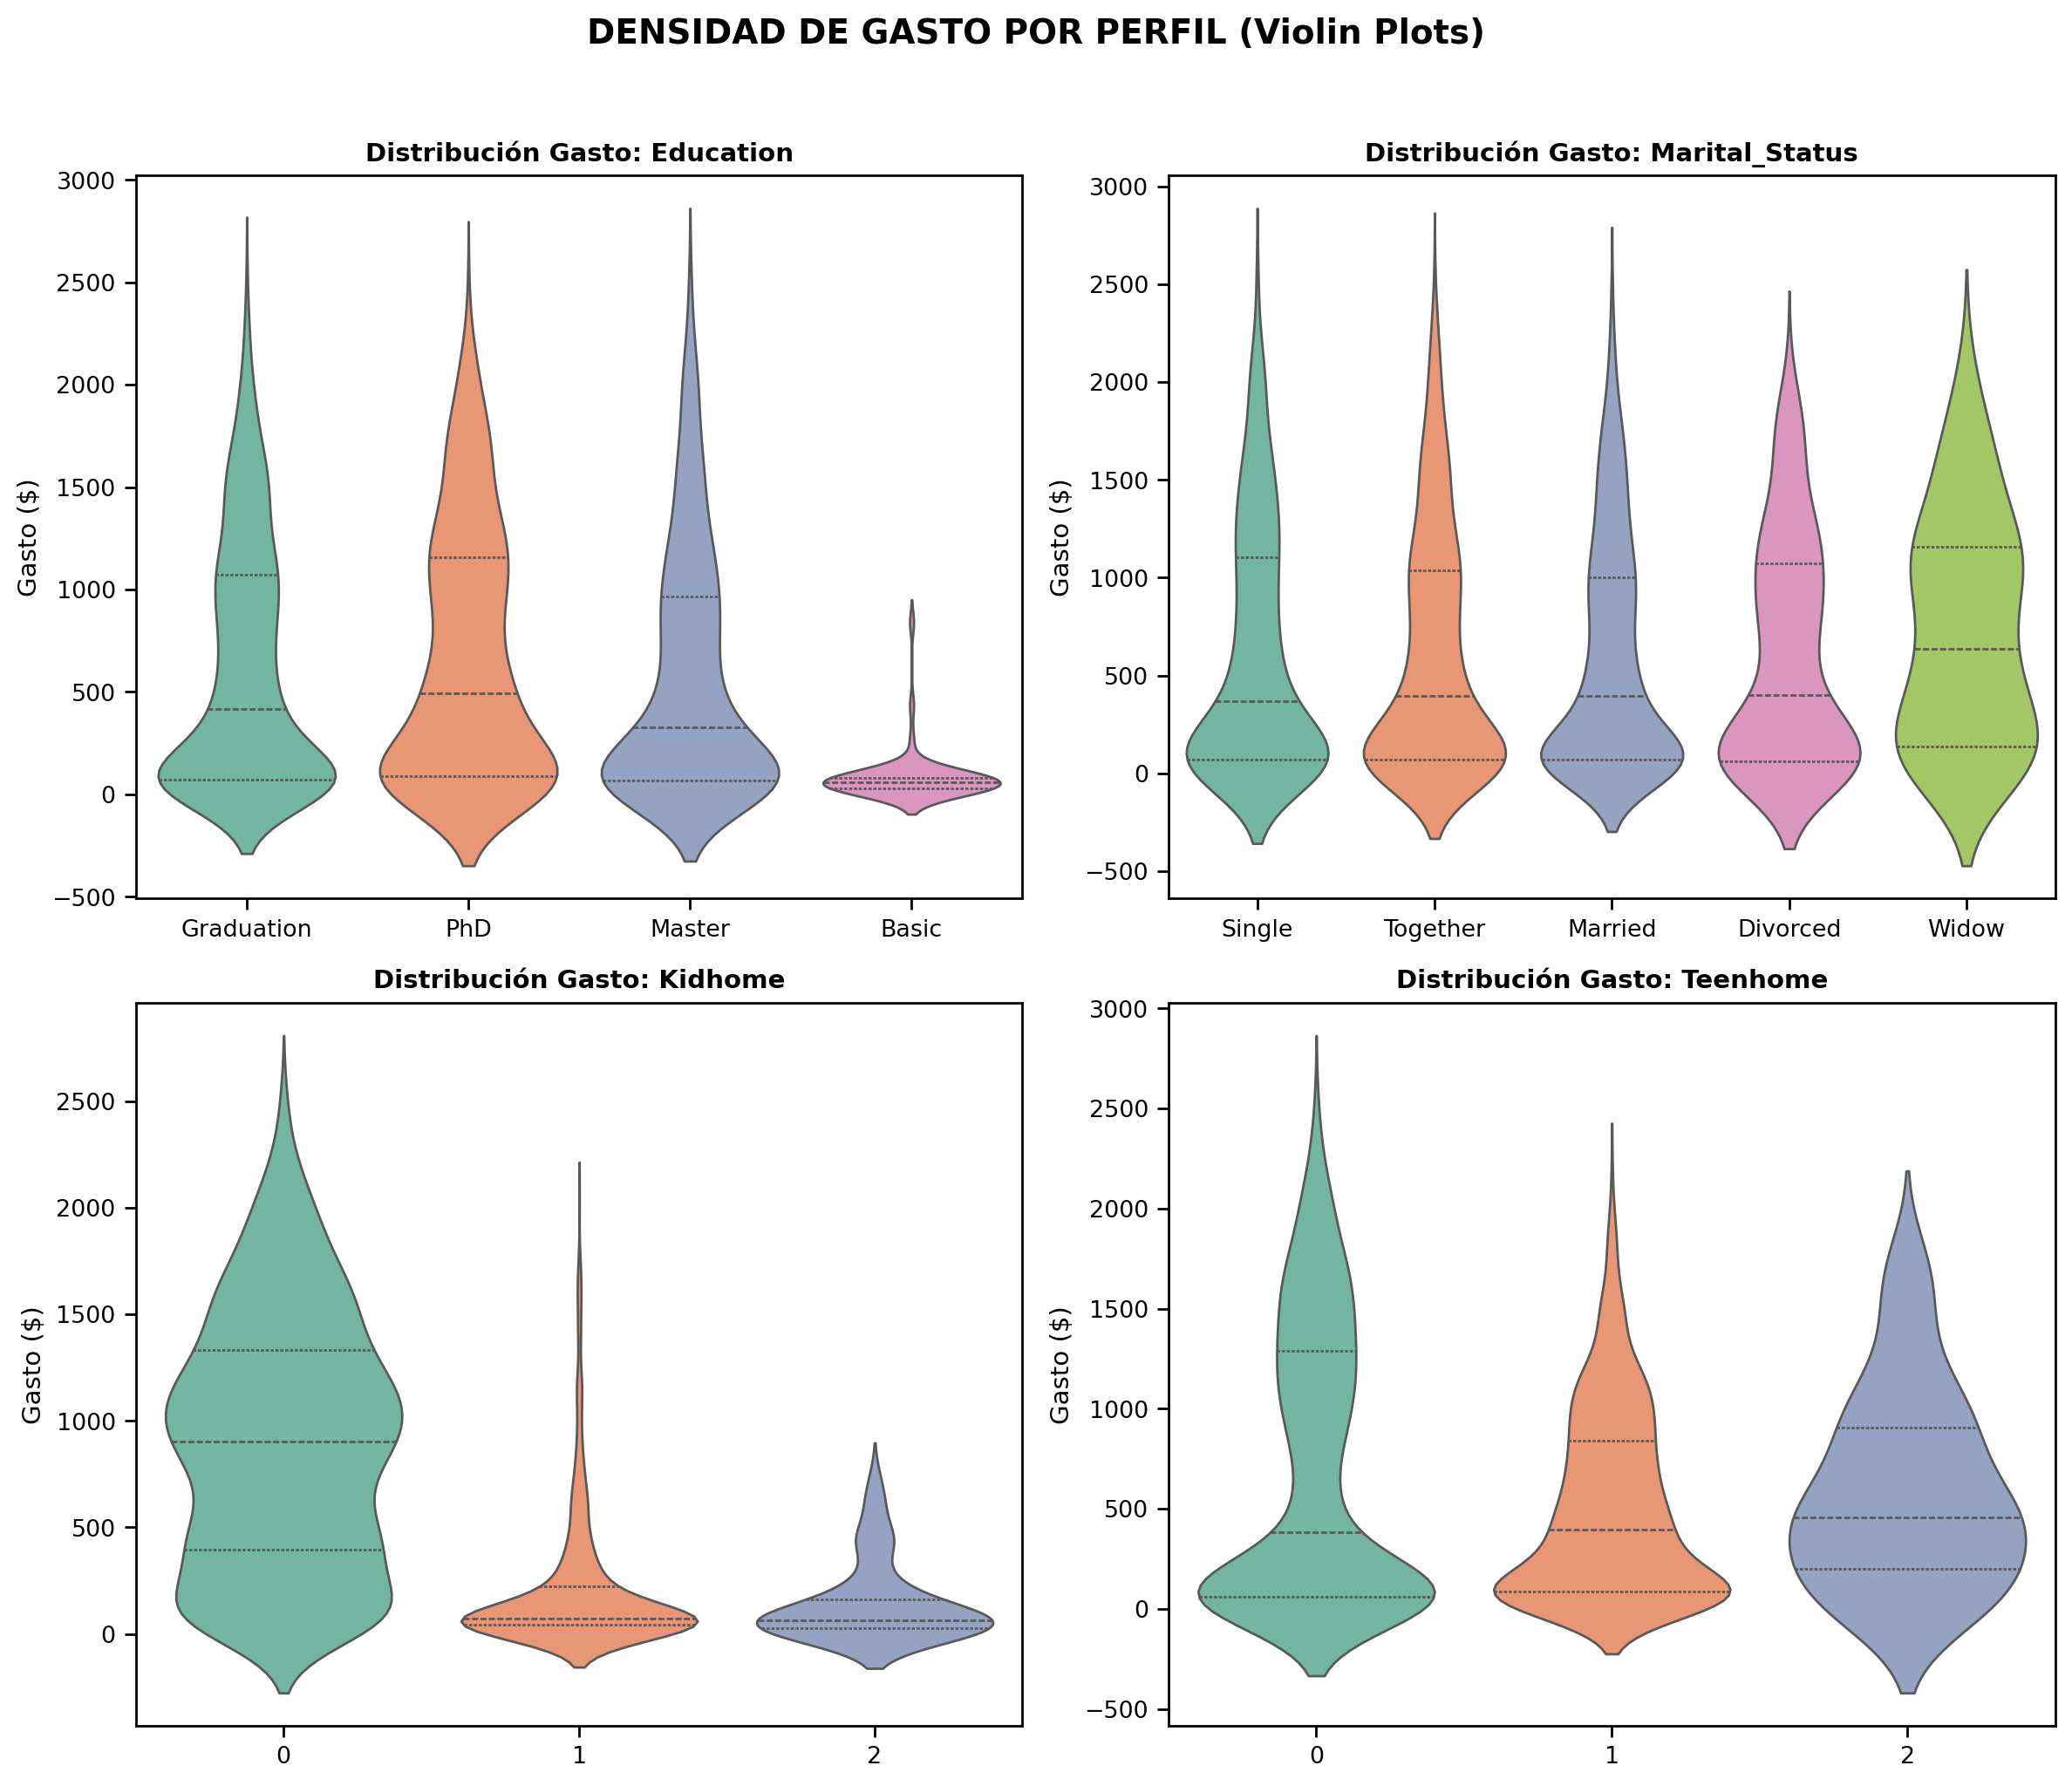

In [26]:
sns.set_context("paper", font_scale=1.1)

vars_graf_A = [c for c in vars_cat_perfil if c in df_clean.columns]

fig, axes = plt.subplots(len(vars_graf_A) // 2 + len(vars_graf_A) % 2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(vars_graf_A):
    sns.violinplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i],
                   palette='Set2', hue=col, legend=False, inner="quartile")

    axes[i].set_title(f'Distribución Gasto: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Gasto ($)')

plt.suptitle("DENSIDAD DE GASTO POR PERFIL (Violin Plots)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Análisis de Densidad de Gasto (Violin Plots)**

Los gráficos de violín revelan la **estructura interna** de los grupos, mostrando matices que los promedios esconden.

**1. El "Ancla" de los Hijos (`Kidhome` - Abajo Izquierda):**
* **La Diferencia Visual:** Es el contraste más brutal del dashboard.
    * **0 Hijos (Forma de Guitarra):** La densidad está repartida. Hay una base sólida, pero el cuerpo del violín se ensancha hacia arriba (alrededor de 1000$-1500$). Esto indica una clase media-alta robusta.
    * **1/2 Hijos (Forma de Gota):** Toda la masa colapsa hacia el suelo (gasto < 200$). El "cuello" del violín es finísimo, lo que significa que es **extremadamente raro** encontrar a alguien con hijos pequeños que gaste mucho.
* **Conclusión:** Tener hijos pequeños no solo baja el promedio, sino que **homogeneiza** el comportamiento a la baja.

**2. La Homogeneidad Civil (`Marital_Status` - Arriba Derecha):**
* **Formas Idénticas:** Si tapas las etiquetas de abajo, sería casi imposible distinguir entre `Single`, `Married`, `Divorced` o `Together`. Todos tienen la misma forma de "botella": base ancha (muchos gastan poco) y cuello largo (unos pocos gastan mucho).
* **La Excepción "Viuda" (`Widow`):** Como también hemos visto antes, es el único violín ligeramente diferente. Su "barriga" (la zona más ancha) está un poco más elevada que el resto. Posiblemente debido a que suelen ser personas mayores con patrimonio acumulado y sin cargas familiares.

**3. La Trampa de la Educación Básica (`Education` - Arriba Izquierda):**
* **El Violín Aplastado:** Si nos fijamos en la categoría `Basic`. No es un violín, es una "tortita". No tiene cuello hacia arriba.
* Esto confirma que el nivel educativo básico es un **techo de cristal** absoluto. Mientras que `Graduation`, `Master` y `PhD` tienen formas similares con potencial de alto gasto, `Basic` garantiza bajo valor.

**4. Niños vs. Adolescentes (`Teenhome` - Abajo Derecha):**
* Comparando `Kidhome` con `Teenhome`, vemos que el efecto de los adolescentes es **menos severo**.
* El violín de "1 Adolescente" (naranja) tiene una "cintura" más ancha que el de "1 Niño". Esto sugiere que, a medida que los hijos crecen, el consumo de lujo se recupera levemente, aunque nunca llega al nivel de los "Sin Hijos".

#### Análisis de Densidad: Impacto del Marketing (Violin Plots)
Finalmente, generamos los violin plots para las variables del Grupo C (Promociones) para entender cómo la aceptación de campañas pasadas afecta la distribución del gasto.

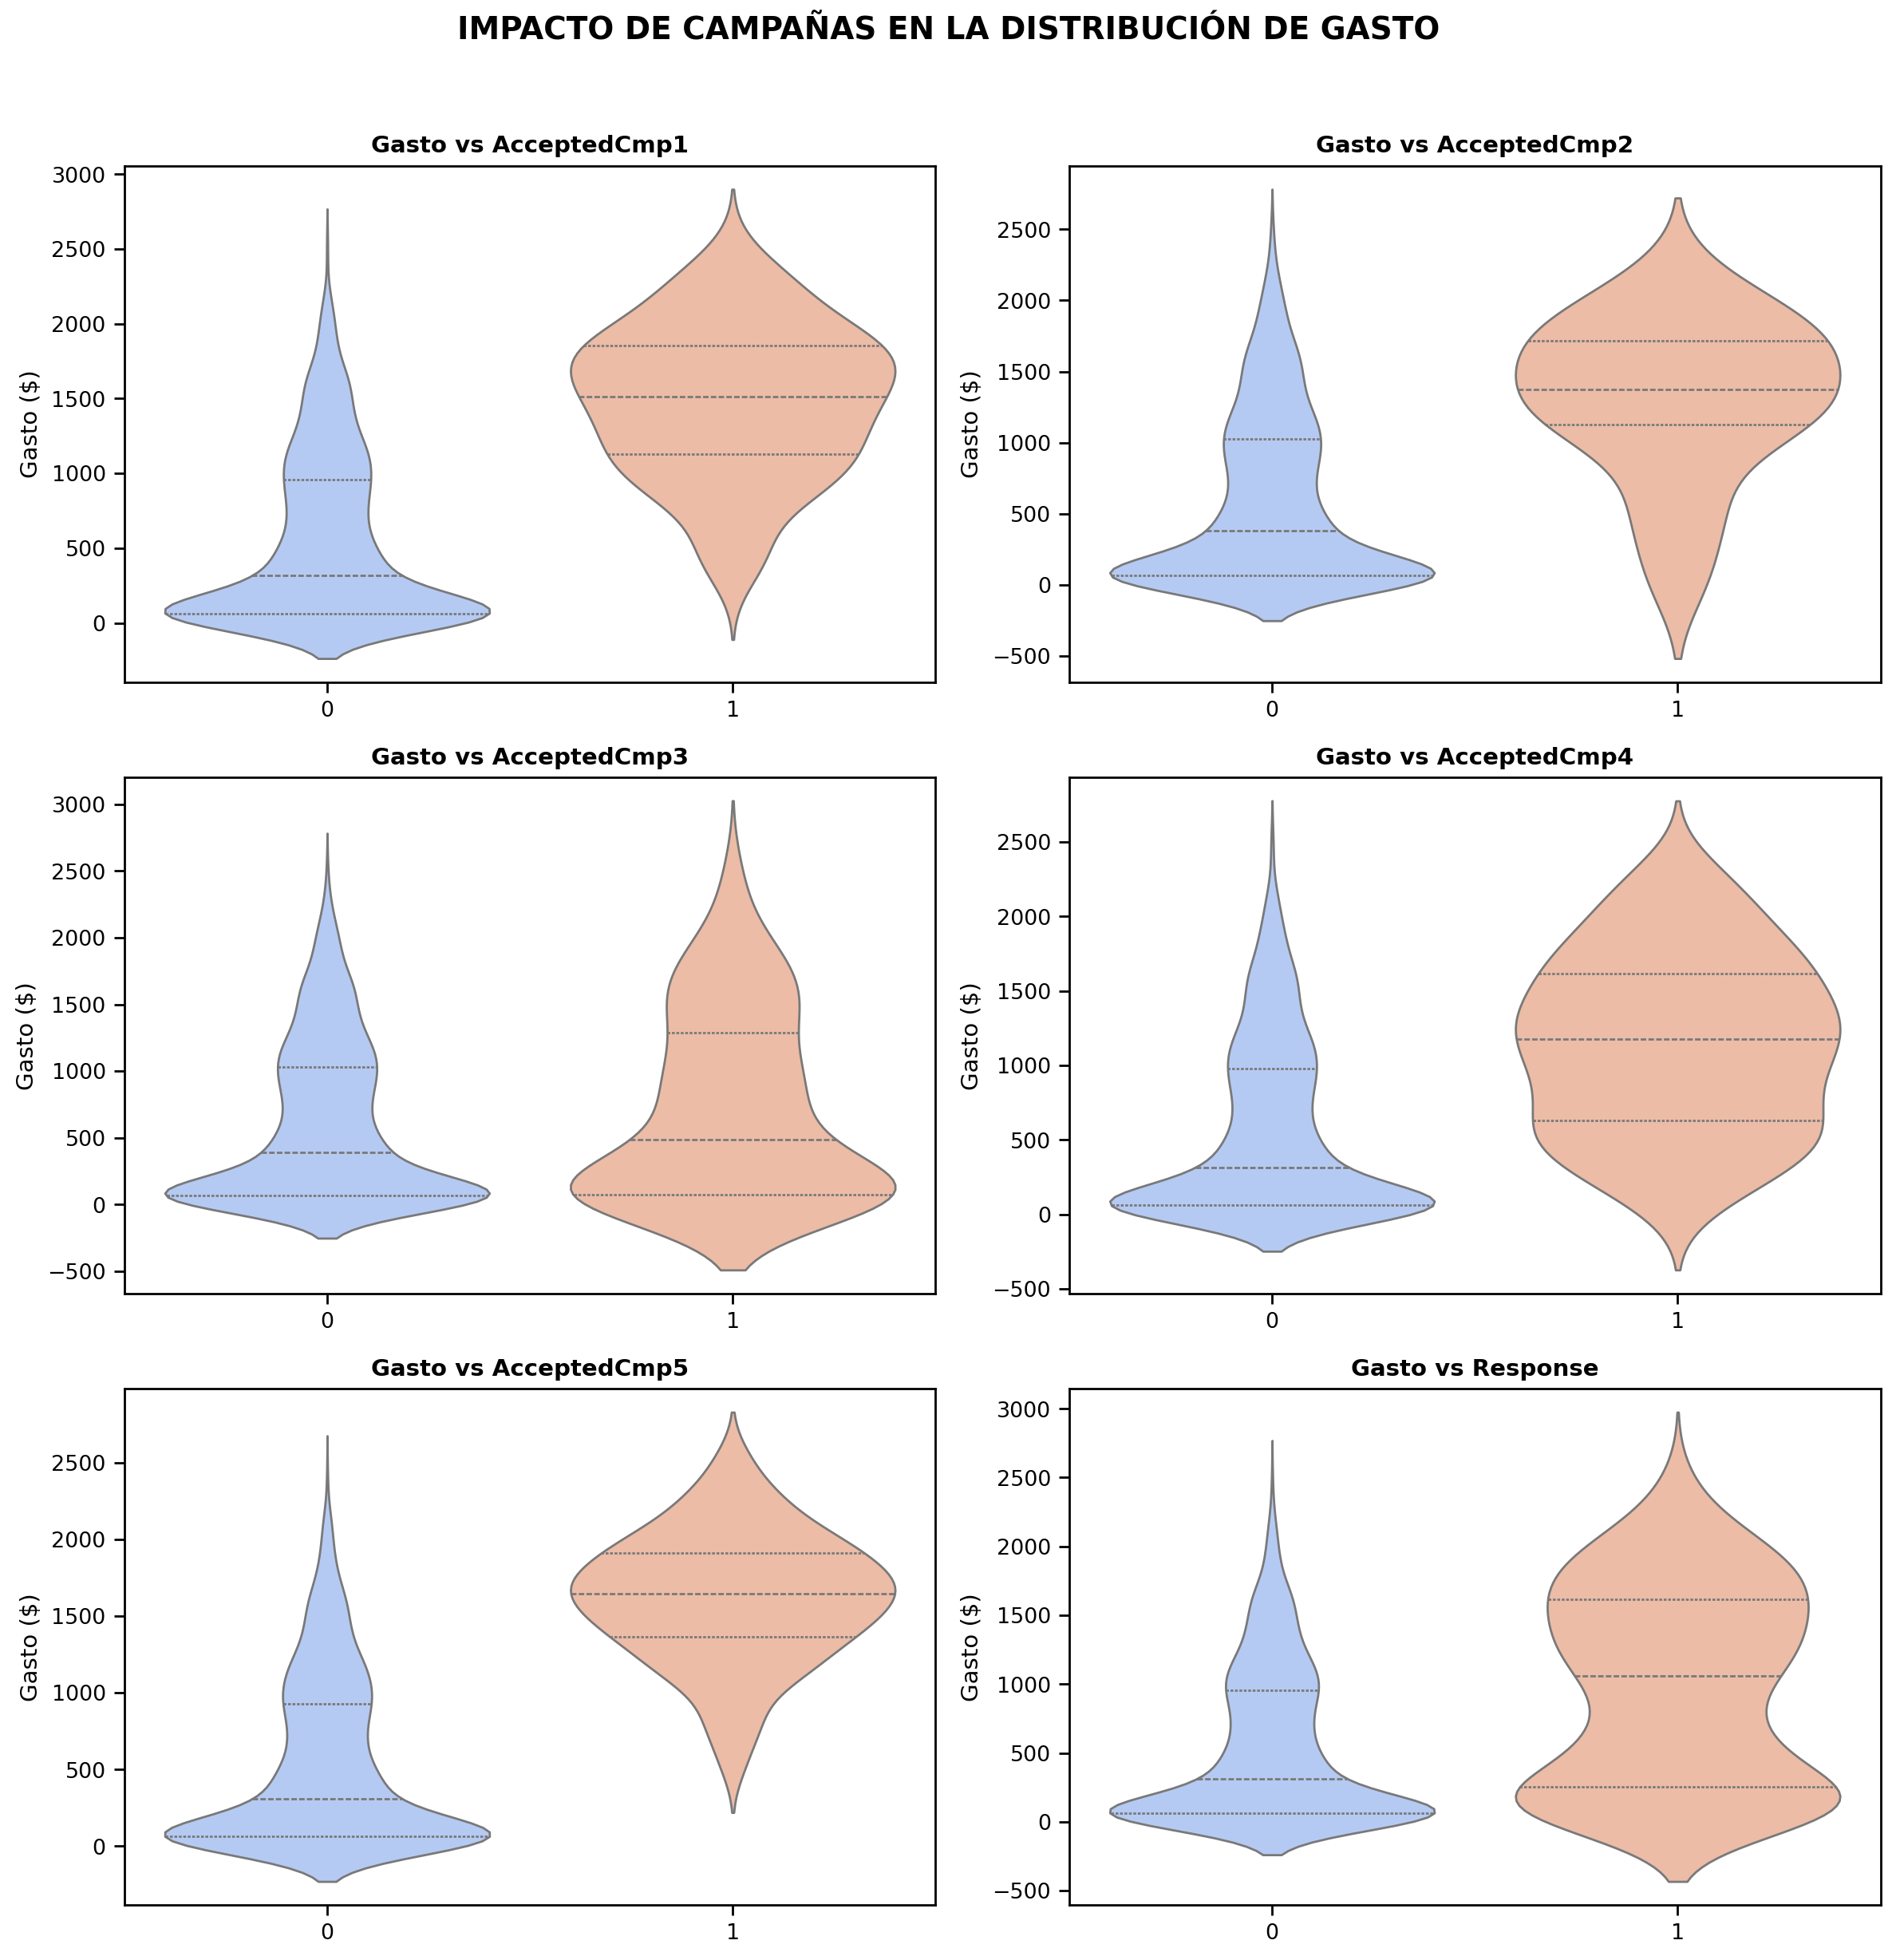

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(vars_cat_promo):
    sns.violinplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i],
                   palette='coolwarm', hue=col, legend=False, inner="quartile")

    axes[i].set_title(f'Gasto vs {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Gasto ($)')

plt.suptitle("IMPACTO DE CAMPAÑAS EN LA DISTRIBUCIÓN DE GASTO", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

sns.set_context("notebook")

#### **Análisis de Densidad: Impacto del Marketing (Violin Plots)**

Estos gráficos confirman que las campañas de marketing actúan como un filtro casi perfecto de poder adquisitivo. La diferencia de forma entre el grupo "0" (Azul - Rechazo) y el grupo "1" (Naranja - Aceptación) es estructural:

**1. La Morfología del Rechazo (Violines Azules):**
* **Forma de "Base Pesada":** En las 6 gráficas, los violines azules tienen toda su masa concentrada en el suelo (gasto < 500$).
* El comportamiento "por defecto" del cliente de bajo valor es ignorar las campañas. Si un cliente rechaza todas las campañas, hay una probabilidad altísima de que pertenezca al clúster de bajo presupuesto.

**2. La Morfología de la Aceptación (Violines Naranjas):**
* **El "Rombo Elevado" (Cmp1, Cmp2, Cmp4, Cmp5):**
    * Si nos fijamos en `AcceptedCmp2` o `AcceptedCmp4`. El violín naranja casi no toca el suelo. Su parte más ancha está flotando arriba, alrededor de los 1.500$.
    * Es prácticamente imposible que un cliente de bajo valor acepte estas campañas. Son ofertas diseñadas exclusivamente para la élite.
* **La Excepción (`AcceptedCmp3`):**
    * Este violín es diferente. Su base es más ancha y baja que las otras campañas naranjas.
    * La Campaña 3 fue menos "elitista" y logró atraer a un rango más amplio de bolsillos, incluyendo algunos de gasto medio-bajo.

**3. La Evolución Final (`Response`):**
* El último gráfico resume la situación actual. Aunque hemos conseguido que más gente acepte (el violín naranja es más "gordo" que en campañas pasadas), la separación sigue siendo nítida.
* El violín naranja de `Response` tiene una forma de "reloj de arena" muy suave, indicando que capturamos clientes de clase media y alta, pero seguimos filtrando eficazmente a los de gasto nulo.

**Conclusión para el Modelo:**
Las variables de campaña son **predictores deterministas**.
* Si `AcceptedCmpX == 1`  La probabilidad de que el cliente sea del Clúster "VIP" es cercana al 100%.
* El algoritmo utilizará estas variables para separar con cirugía de precisión a los mejores clientes.

## 2. Procesado inicial de los datos ``(1.5p)``

En este apartado se tiene que elegir las variables que se van a utilizar para los modelos que se usarán posteriormente, se tiene que hacer selección de variables con estudio de correlaciónes ``(0.75p)`` y PCA ``(0.75p)``.

###  Selección de Variables y Estudio de Correlaciones
Para preparar el dataset para los modelos de clustering, primero transformamos las variables categóricas (Education, Marital_Status) mediante codificación numérica (Ordinal y Label Encoding respectivamente).

Posteriormente, realizamos una selección de variables basada en el análisis de correlaciones del apartado anterior. Para evitar problemas de multicolinealidad y redundancia, eliminamos las variables agregadas:
* `Total_Spend`: Se elimina porque su información ya está contenida en la suma de las 6 categorías de productos (MntWines, MntMeat, etc.). Mantener el desglose es vital para segmentar por preferencias de consumo.
* `Children_Total`: Se elimina en favor de Kidhome y Teenhome, ya que el EDA demostró que los niños pequeños y los adolescentes tienen impactos muy distintos en el gasto.

In [28]:
df_model = df_clean.copy()

mapa_edu = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df_model['Education'] = df_model['Education'].map(mapa_edu)
print(">> Educación codificada numéricamente.")

le = LabelEncoder()
df_model['Marital_Status'] = le.fit_transform(df_model['Marital_Status'])
print(f">> Estado Civil codificado: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nDimensiones actuales: {df_model.shape}")
df_model.head(3)

>> Educación codificada numéricamente.
>> Estado Civil codificado: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2), 'Together': np.int64(3), 'Widow': np.int64(4)}

Dimensiones actuales: (2236, 28)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Age,Antiguedad,Total_Spend,Children_Total,Total_Accepted_Cmp
0,1,2,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,58,849,1617,0,1
1,1,2,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,61,299,27,2,0
2,1,3,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,50,498,776,0,0


>> Variables eliminadas por redundancia (Correlación): ['Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']


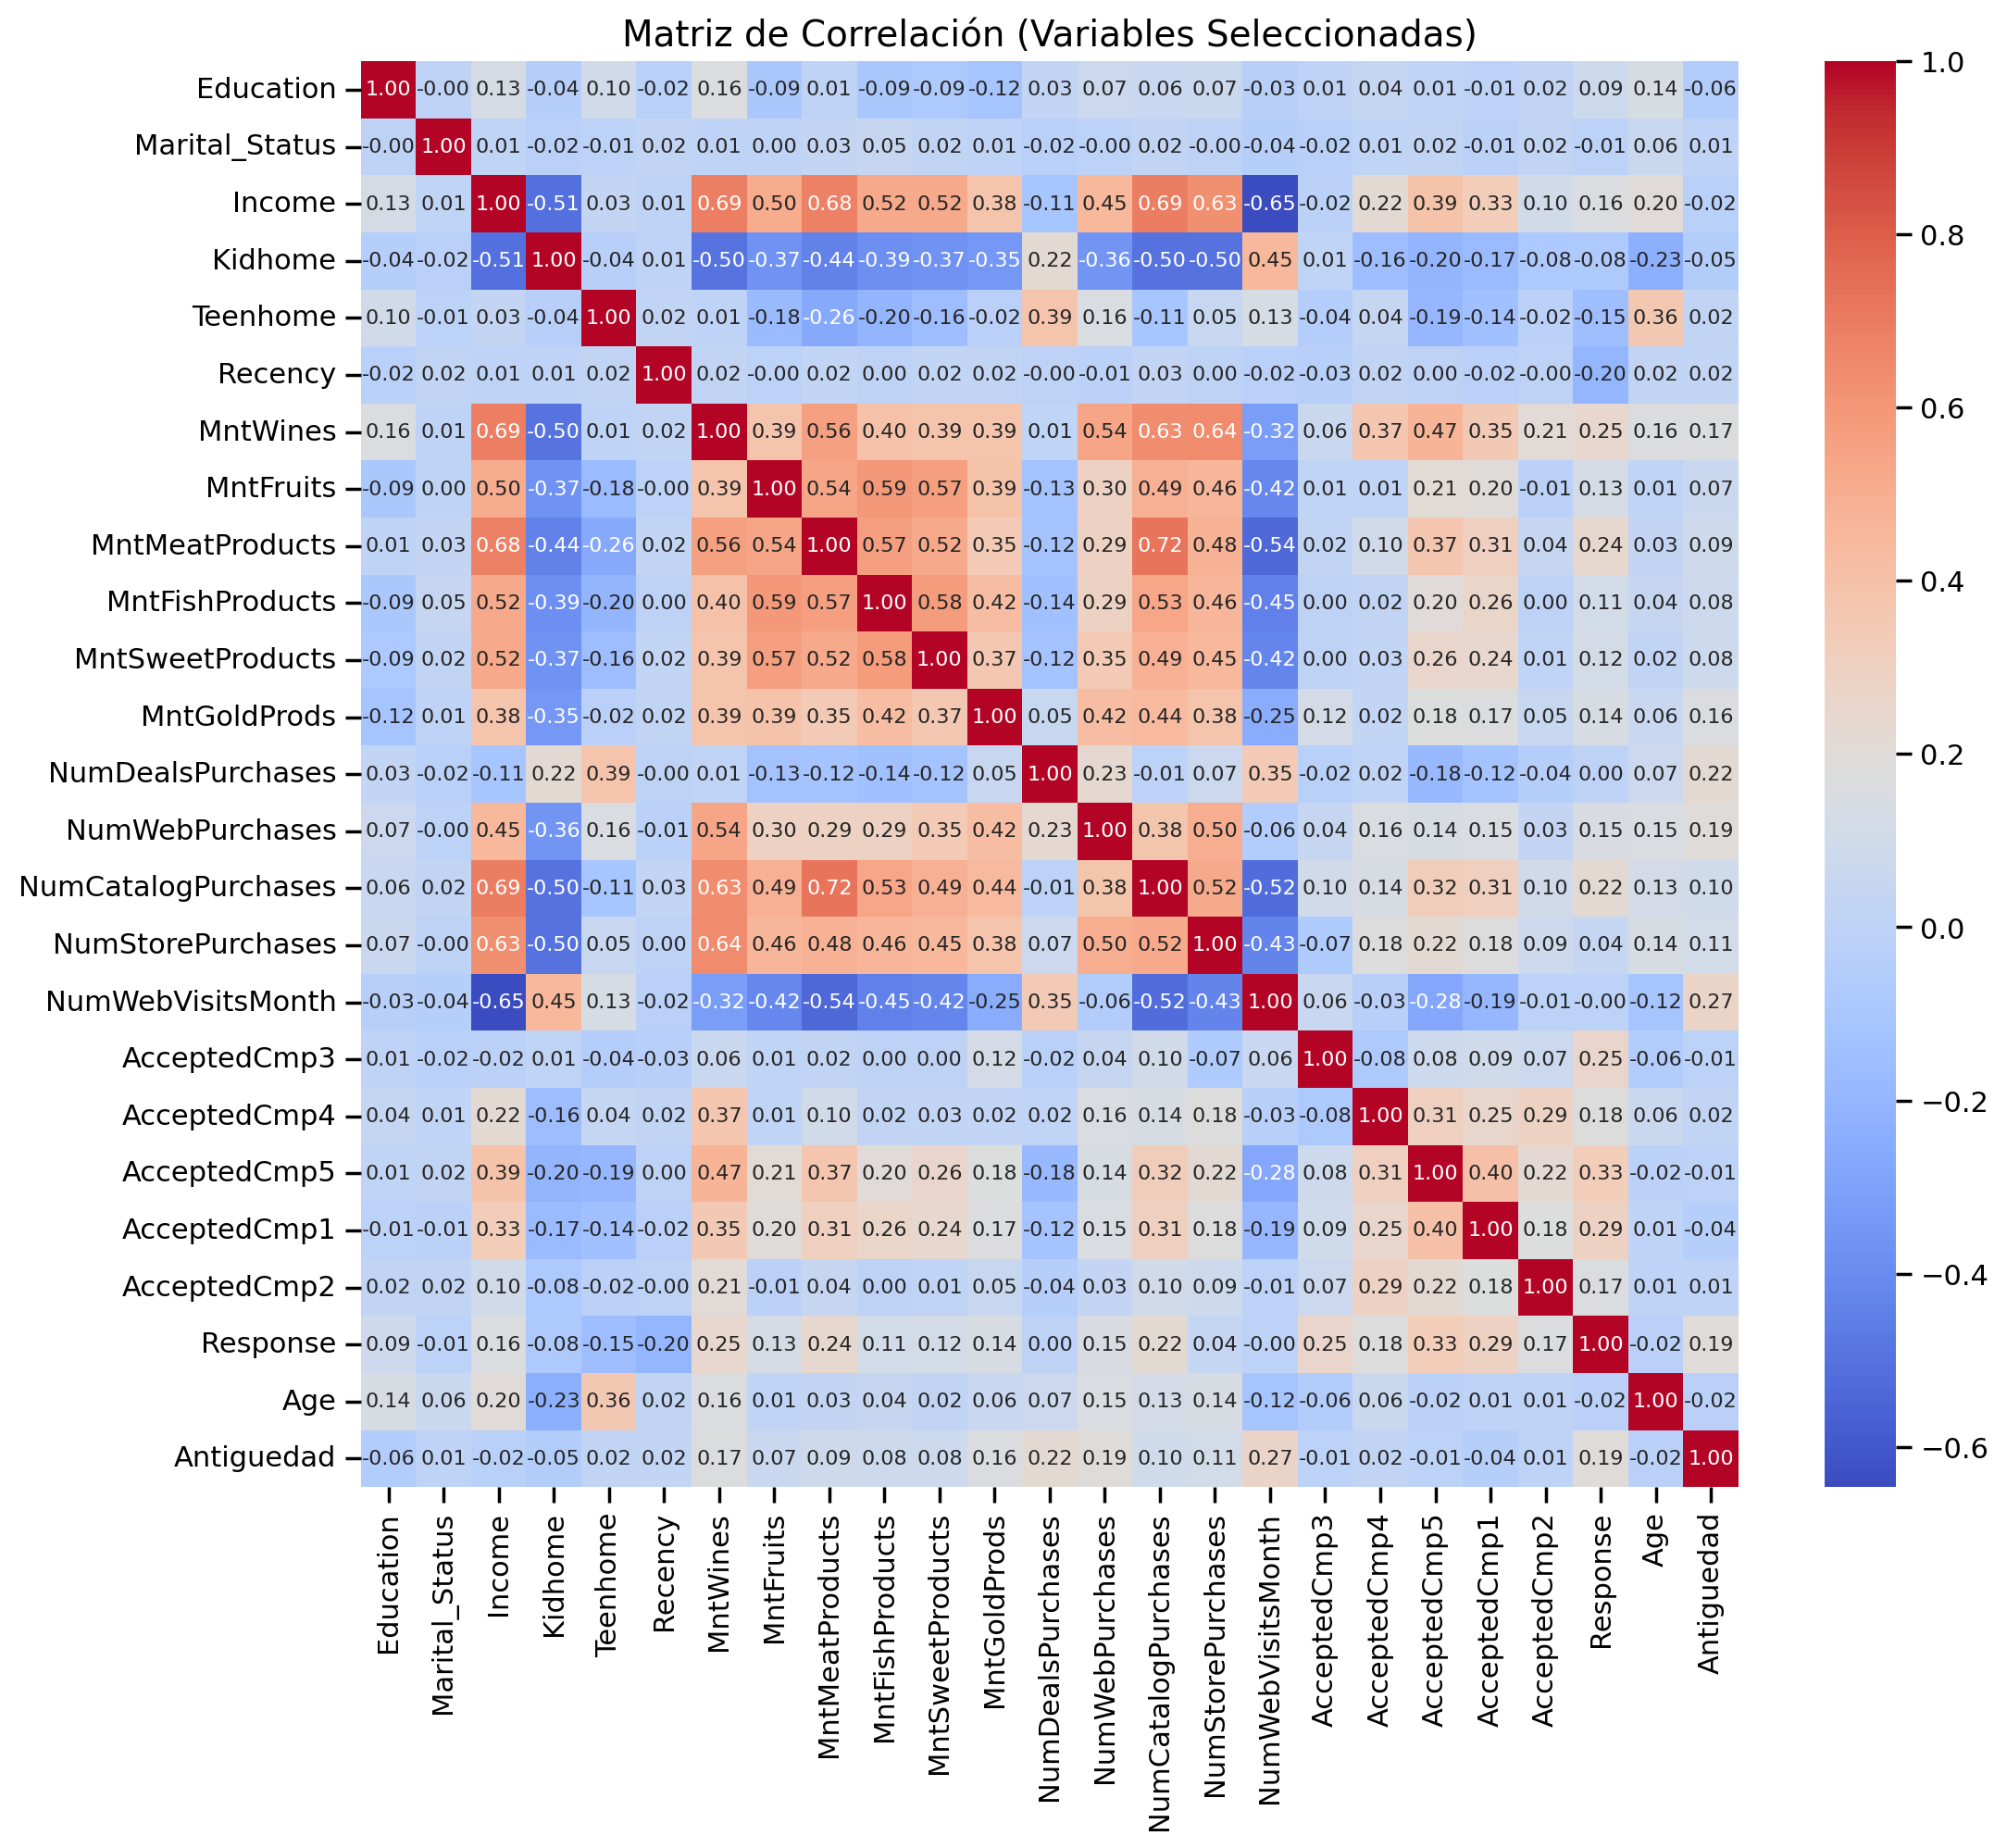

In [29]:
corr_matrix = df_model.corr().abs()

cols_redundantes = ['Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']
cols_drop = [c for c in cols_redundantes if c in df_model.columns]

df_model = df_model.drop(columns=cols_drop)

print(f">> Variables eliminadas por redundancia (Correlación): {cols_drop}")

plt.figure(figsize=(12, 10))
sns.heatmap(df_model.corr(), cmap='coolwarm', annot=True, fmt=".2f",annot_kws={"size": 8})
plt.title("Matriz de Correlación (Variables Seleccionadas)", fontsize=14)
plt.show()

#### **Análisis de la Matriz de Correlación Final (Post-Selección)**

Tras la eliminación de las variables agregadas (`Total_Spend`, `Children_Total`), la matriz de correlación muestra una estructura saludable y lista para el modelado:

1. **Ausencia de Multicolinealidad Crítica:**
* Ya no existen coeficientes superiores a **0.90** entre variables distintas. Esto confirma que hemos eliminado la redundancia matemática directa. Cada variable aporta información única.

2. **Persistencia de "Drivers" de Negocio (Correlaciones 0.5 - 0.7):**
* Observamos correlaciones fuertes (pero no perfectas) que reflejan la lógica del negocio. Por ejemplo:
    * **Income vs. MntWines (0.69):** Confirma que el vino es el producto principal asociado al poder adquisitivo.
    * **Income vs. NumCatalogPurchases (0.69):** Indica que el canal de catálogo es exclusivo de rentas altas.
* Estas correlaciones no deben eliminarse manualmente, ya que representan patrones de comportamiento reales. Sin embargo, su existencia justifica plenamente el uso de **PCA** en el siguiente paso para sintetizar estas relaciones en componentes ortogonales.

3. **Relaciones Inversas Clave (Azul):**
* Destaca la correlación negativa entre **Kidhome** e **Income (-0.51)** y **MntWines (-0.50)**. Esto valida matemáticamente lo visto en el EDA: la presencia de niños pequeños actúa como un freno estructural al consumo de lujo.

**Conclusión:**
El dataset `df_model` contiene ahora 25 variables numéricas limpias y correlacionadas orgánicamente, listas para la reducción de dimensionalidad.

Siguiente Paso: PCA y Gráfico de Codo
Ahora que tenemos las variables definitivas, vamos a comprimirlas. El PCA cogerá esas variables que se parecen (como Income y MntWines) y las fusionará en un "Super-Componente".

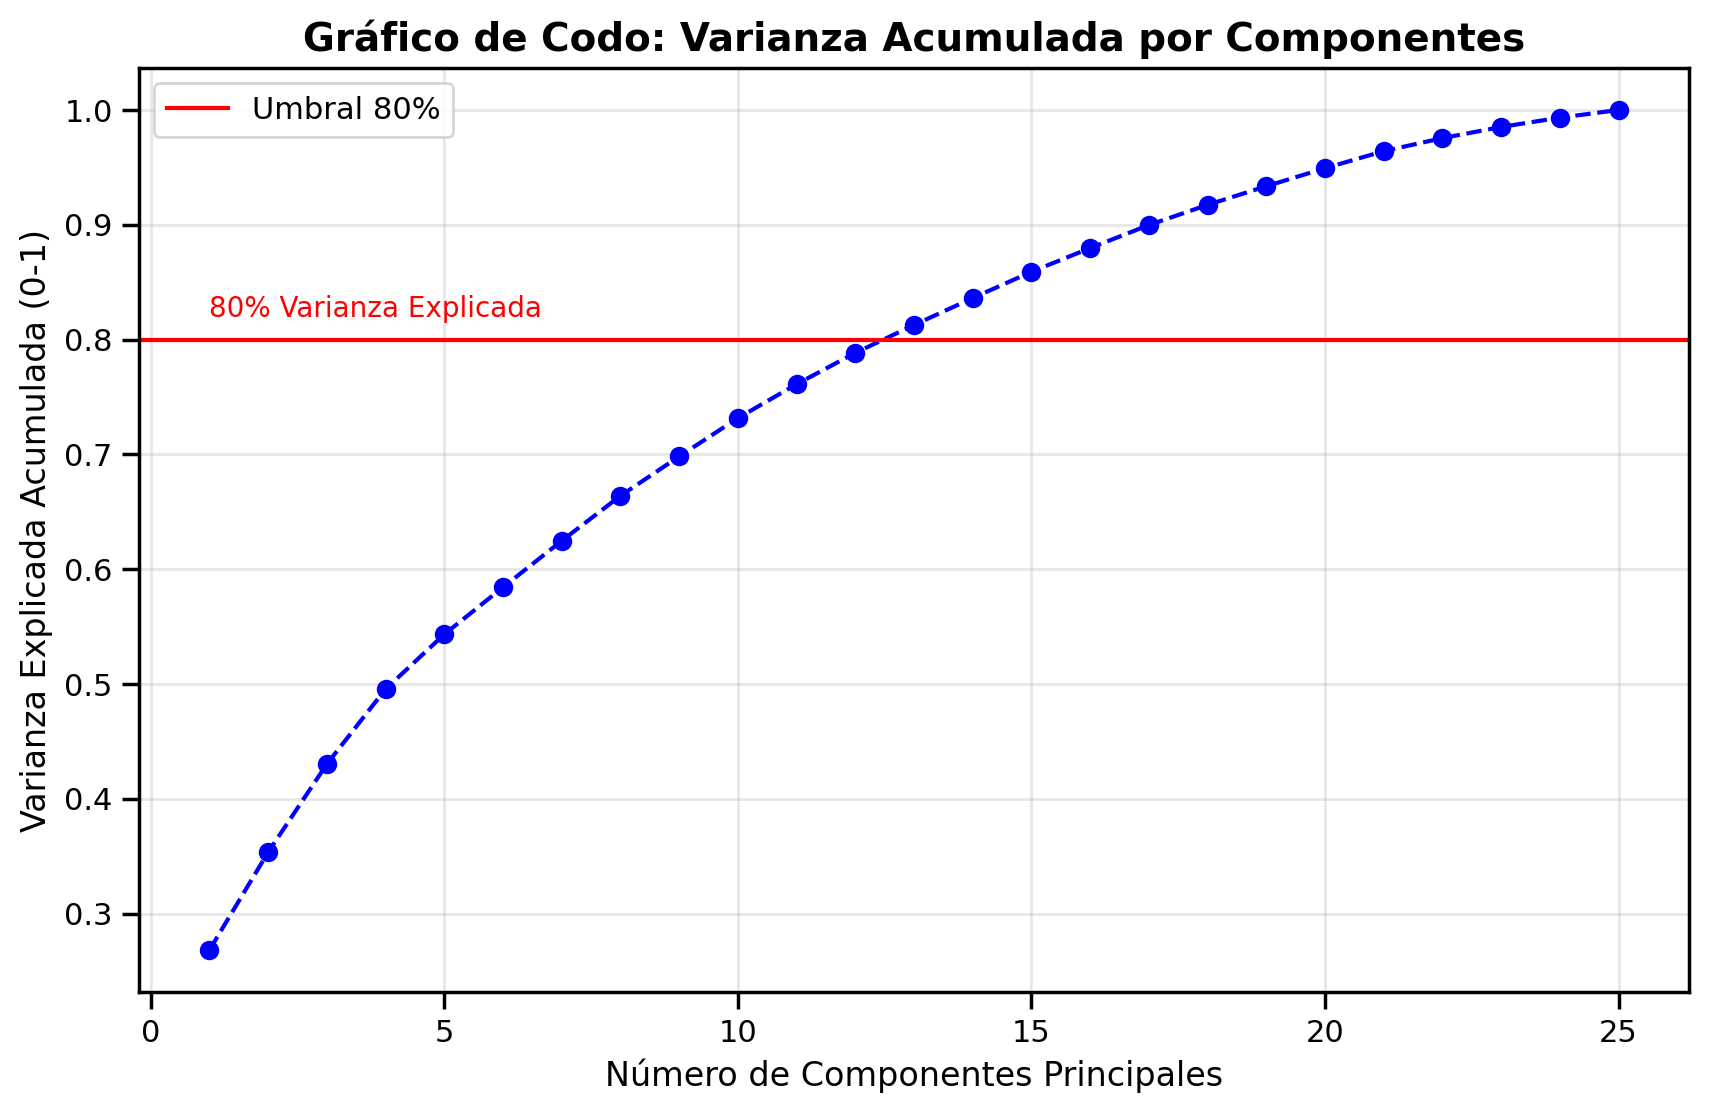

--- RESULTADO PCA ---
Para explicar el 80% de la información, necesitamos 13 componentes.


In [30]:
# --- 2.3 y 2.4 PCA: ANÁLISIS DE VARIANZA ---

# 1. Escalado (OBLIGATORIO para PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

# 2. Ajustamos PCA con todos los componentes posibles
pca = PCA()
pca.fit(df_scaled)

# 3. Calculamos la varianza acumulada
varianza_acum = pca.explained_variance_ratio_.cumsum()

# 4. Gráfico de Codo (Elbow Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum, marker='o', linestyle='--', color='b')

# Línea de corte al 80% (Criterio estándar)
plt.axhline(y=0.80, color='r', linestyle='-', label='Umbral 80%')
plt.text(1, 0.82, '80% Varianza Explicada', color='red', fontsize=10)

# Etiquetas
plt.title('Gráfico de Codo: Varianza Acumulada por Componentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada (0-1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Cálculo exacto de componentes para el 80%
n_components = (varianza_acum < 0.80).sum() + 1
print(f"--- RESULTADO PCA ---")
print(f"Para explicar el 80% de la información, necesitamos {n_components} componentes.")

#### **2.3 Análisis de Componentes Principales (PCA)**

El gráfico de Varianza Acumulada muestra cómo cada componente adicional aporta información al modelo.

* **Interpretación:** La curva tiene un crecimiento constante, lo que indica que la información está repartida entre varias variables y no concentrada en solo una o dos.
* **Punto de Corte:** Siguiendo el criterio estándar de conservar al menos el **80% de la varianza original** para no perder patrones importantes, el gráfico indica que necesitamos **13 componentes**.
* **Resultado:** Hemos logrado reducir la complejidad del problema de 25 variables a 13 componentes principales ("Super-variables"), eliminando el ruido y la redundancia, lo que facilitará enormemente el trabajo de algoritmos geométricos como K-Means y DBSCAN.

PASO FINAL: Creación del Dataset PCA
Vamos a generar el DataFrame definitivo (df_pca) con esos 13 componentes. Este será la "gasolina" para tus 4 modelos de clustering.

In [31]:
# --- 2.4 GENERACIÓN DEL DATASET PCA FINAL ---

# 1. Configuramos PCA con el número óptimo detectado
n_componentes_optimos = 13
pca_final = PCA(n_components=n_componentes_optimos)

# 2. Transformamos los datos escalados
pca_data = pca_final.fit_transform(df_scaled)

# 3. Creamos el DataFrame limpio para los modelos
cols_pca = [f'PC{i}' for i in range(1, n_componentes_optimos + 1)]
df_pca = pd.DataFrame(data=pca_data, columns=cols_pca)

# 4. Verificación
print(f"--- PRE-PROCESADO COMPLETADO ---")
print(f"Dataset original: {df_model.shape} (Filas, Variables)")
print(f"Dataset PCA:      {df_pca.shape} (Filas, Componentes)")
print(f"\nVarianza total explicada: {pca_final.explained_variance_ratio_.sum() * 100:.2f}%")
print("\nPrimeras filas listas para Clustering:")
display(df_pca.head(3))

--- PRE-PROCESADO COMPLETADO ---
Dataset original: (2236, 25) (Filas, Variables)
Dataset PCA:      (2236, 13) (Filas, Componentes)

Varianza total explicada: 81.27%

Primeras filas listas para Clustering:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,3.791984,0.307863,-0.182872,2.826972,0.174745,0.773365,0.962712,0.387862,-0.793682,1.529693,1.165591,0.301592,-0.620876
1,-2.407383,-0.280256,-0.444501,-1.407221,0.377223,0.683797,-0.173858,-1.121413,0.713924,0.835641,0.714760,-0.353165,-0.006078
2,1.667758,-0.324031,-1.171564,-0.029858,-0.130972,0.606430,1.113135,-0.994233,-0.268060,-0.785675,-0.994305,0.361574,-0.243877


#### **2.4 Resultado Final del Pre-procesado**

Tras aplicar el PCA, hemos transformado el dataset original de 25 variables correlacionadas en un nuevo conjunto de datos (`df_pca`) compuesto por **13 componentes principales** ortogonales (independientes entre sí).

* **Reducción:** De 25 dimensiones a 13.
* **Calidad de la Información:** Estos 13 componentes retienen el **81.27% de la varianza original**.
* **Conclusión:** El dataset `df_pca` está listo para ser ingerido por los algoritmos de clustering. Al haber eliminado el ruido y la redundancia, esperamos que los modelos (K-Means, DBSCAN, etc.) converjan más rápido y produzcan segmentaciones más robustas.

## 3. Clustering ``(5p)``

En este apartado se tienen que utilizar los algoritmos de clustering vistos en clase para hacer la agrupación de los datos.

Se va a pedir que uséis los siguientes modelos:
- Agrupación jerárquica ``(1p)``
- K-means ``(1p)``
- DBSCAN ``(1p)``
- Optics ``(Opcional +0,5p. extras)`` -> _El solamente se aplica si se tiene una nota superior a 5._

La justificación, comparación modelos y explicación del proceso aplicado para hacer el clustering vale ``2p``

## 4. Conclusiones ``(1p)``

Escribid un resumen de lo que se ha hecho y de las decisiones tomadas en cada apartado.